In [7]:
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path

# Configure matplotlib to suppress Chinese character warnings
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')
print('T1', T1.shape, T1.dtype, T1.min(), T1.max())
print('T2', T2.shape, T2.dtype, T2.min(), T2.max())


T1 (352, 512) float64 0.0 769.0
T2 (352, 512) float64 0.0 1127.0


In [11]:
def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img):
    gx = np.array([[ -1, 0, 1], [ -2, 0, 2], [ -1, 0, 1]], dtype=float)
    gy = np.array([[ -1, -2, -1], [ 0, 0, 0], [ 1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img):
    kernel = gaussian_kernel(5, sigma=1.0)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img):
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((5,5)), iterations=20)
    return edge & inner

def postprocess(edge):
    closed = ndi.binary_closing(edge, structure=np.ones((3,3)))
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    return labeled == largest

def project1_pipeline(img, threshold):
    smooth = preprocess(img)
    grad, gx, gy = sobel_gradients(smooth)
    raw_edge = grad > threshold
    inner_edge = remove_brain_edge(raw_edge, img)
    mask = postprocess(inner_edge)
    return smooth, grad, raw_edge, inner_edge, mask


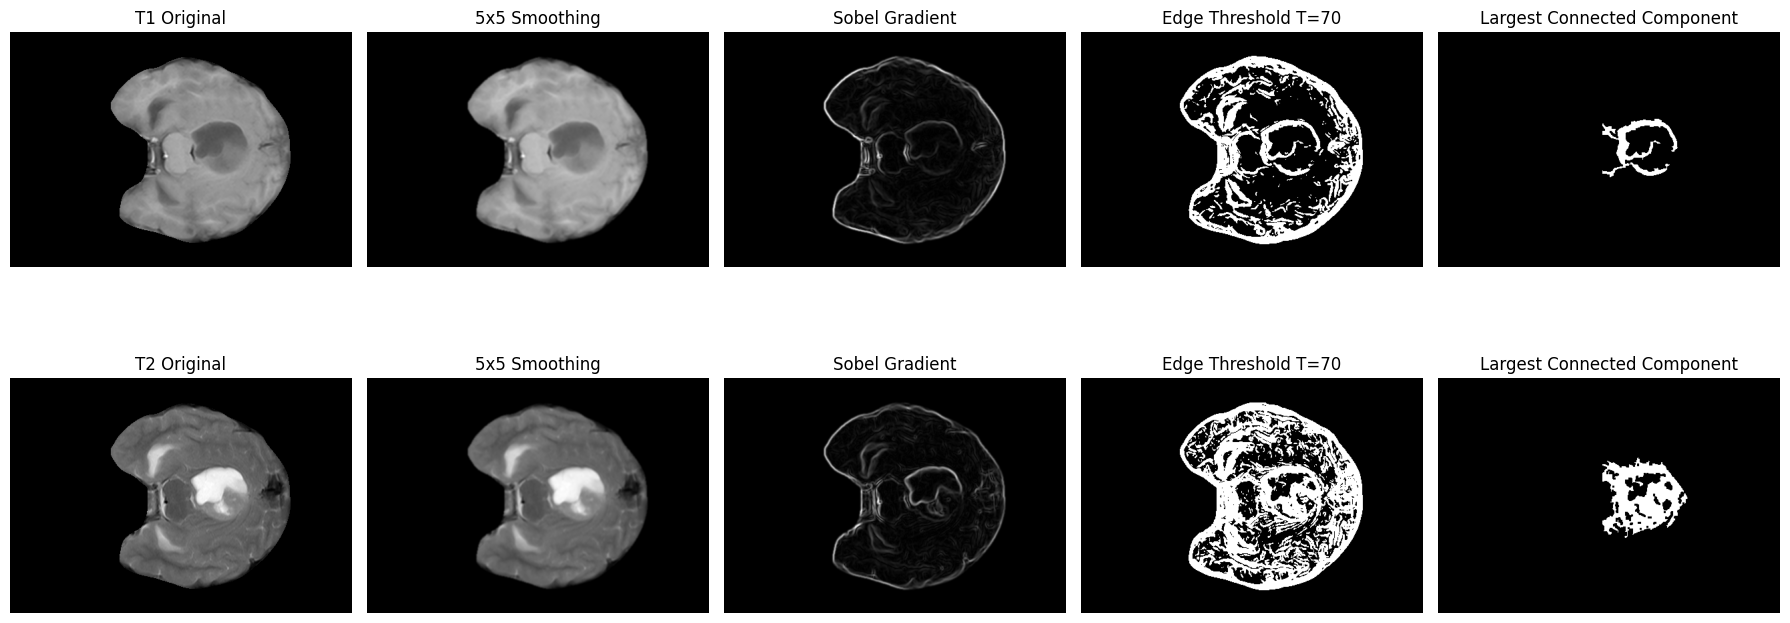

In [6]:
threshold = 70
results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    results[name] = project1_pipeline(img, threshold)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, mask = results[name]
    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')
    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')
    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')
    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold T={threshold}')
    axes[row, 4].imshow(mask, cmap='gray')
    axes[row, 4].set_title('Largest Connected Component')
    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()


In [10]:
# ==================== 修改 postprocess，把闭运算结果也返回 ====================
def postprocess(edge, min_size=50):
    """保留所有面积 >= min_size 的连通域，而非仅最大连通域"""
    closed = ndi.binary_closing(edge, structure=np.ones((3,3)))
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed  # 返回 (closed, mask)
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

def project1_pipeline(img, percentile=92, sigma=2.0):
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img)
    closed, mask = postprocess(inner_edge)
    return smooth, grad, raw_edge, inner_edge, closed, mask


# ==================== 可视化 — 7 列，展示所有中间结果 ====================
percentile = 92
results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    results[name] = project1_pipeline(img, percentile)

fig, axes = plt.subplots(2, 7, figsize=(24, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={percentile}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain Edge')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()


TypeError: preprocess() got an unexpected keyword argument 'sigma'

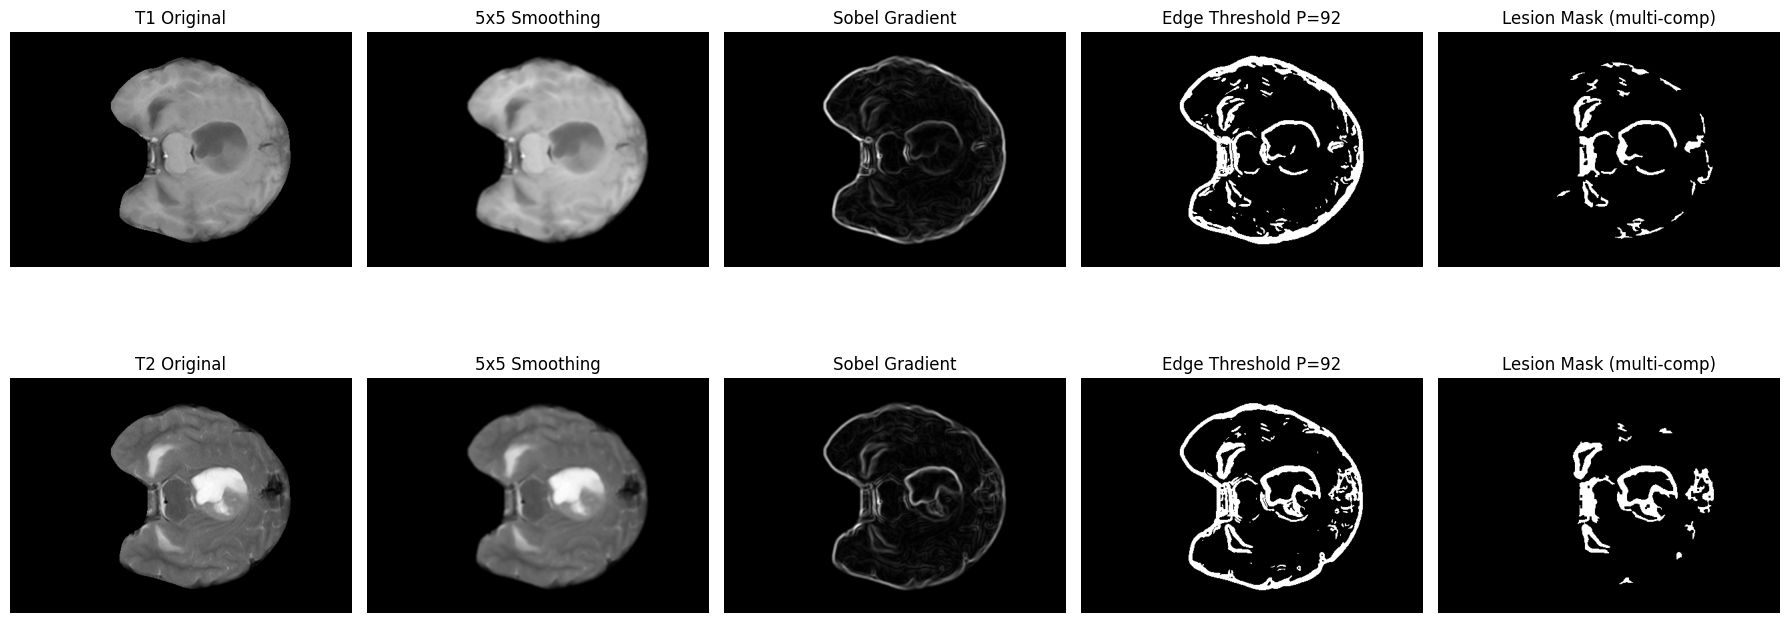

In [24]:
def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img):
    gx = np.array([[ -1, 0, 1], [ -2, 0, 2], [ -1, 0, 1]], dtype=float)
    gy = np.array([[ -1, -2, -1], [ 0, 0, 0], [ 1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=2.0):
    """5x5 高斯平滑，sigma 提高到 2.0 以更好抑制噪声"""
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=3):
    """腐蚀迭代数从 20 降到 6，避免过度去除脑边缘附近病灶"""
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((5,5)), iterations=erosion_iters)
    return edge & inner

def postprocess(edge, min_size=50):
    """保留所有面积 >= min_size 的连通域，而非仅最大连通域"""
    closed = ndi.binary_closing(edge, structure=np.ones((3,3)))
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    return np.isin(labeled, keep_labels)

def project1_pipeline(img, percentile=80, sigma=2.0):
    """使用梯度百分位数作为自适应阈值，替代固定 T=70"""
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img)
    mask = postprocess(inner_edge)
    return smooth, grad, raw_edge, inner_edge, mask

# ==================== 可视化 ====================
percentile = 92
results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    results[name] = project1_pipeline(img, percentile)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, mask = results[name]
    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')
    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')
    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')
    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={percentile}')
    axes[row, 4].imshow(mask, cmap='gray')
    axes[row, 4].set_title('Lesion Mask (multi-comp)')
    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()


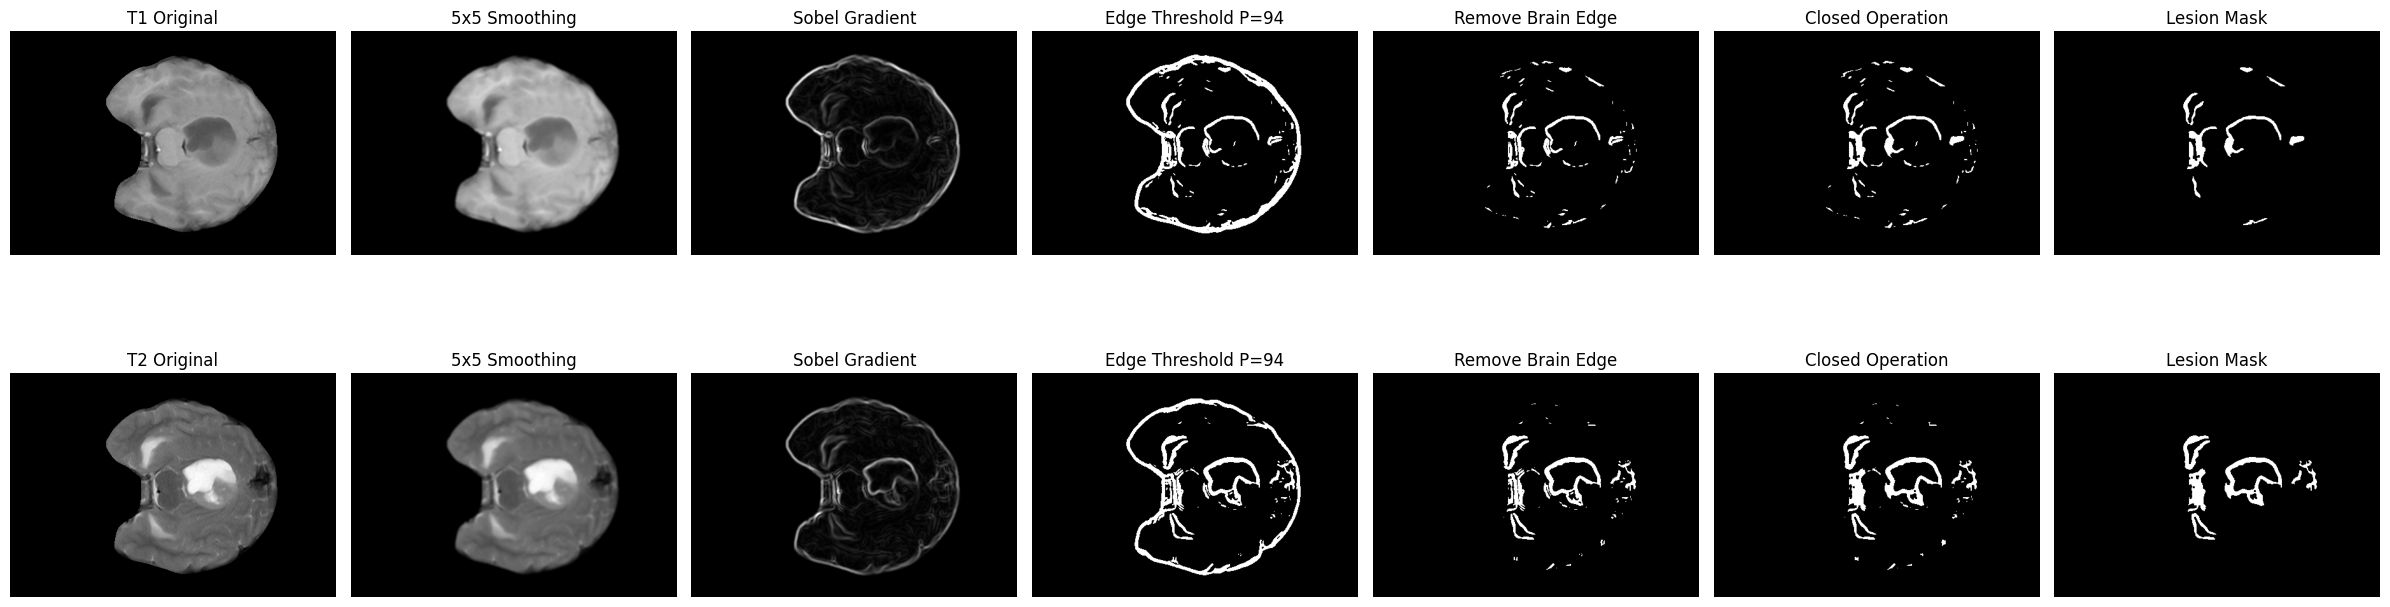

In [26]:
# ==================== 修改 postprocess，把闭运算结果也返回 ====================
def postprocess(edge, min_size=50):
    """保留所有面积 >= min_size 的连通域，而非仅最大连通域"""
    closed = ndi.binary_closing(edge, structure=np.ones((3,3)))
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed  # 返回 (closed, mask)
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

def project1_pipeline(img, percentile=94, sigma=2.0):
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img)
    closed, mask = postprocess(inner_edge)
    return smooth, grad, raw_edge, inner_edge, closed, mask


# ==================== 可视化 — 7 列，展示所有中间结果 ====================
percentile = 94
results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    results[name] = project1_pipeline(img, percentile)

fig, axes = plt.subplots(2, 7, figsize=(24, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={percentile}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain Edge')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()


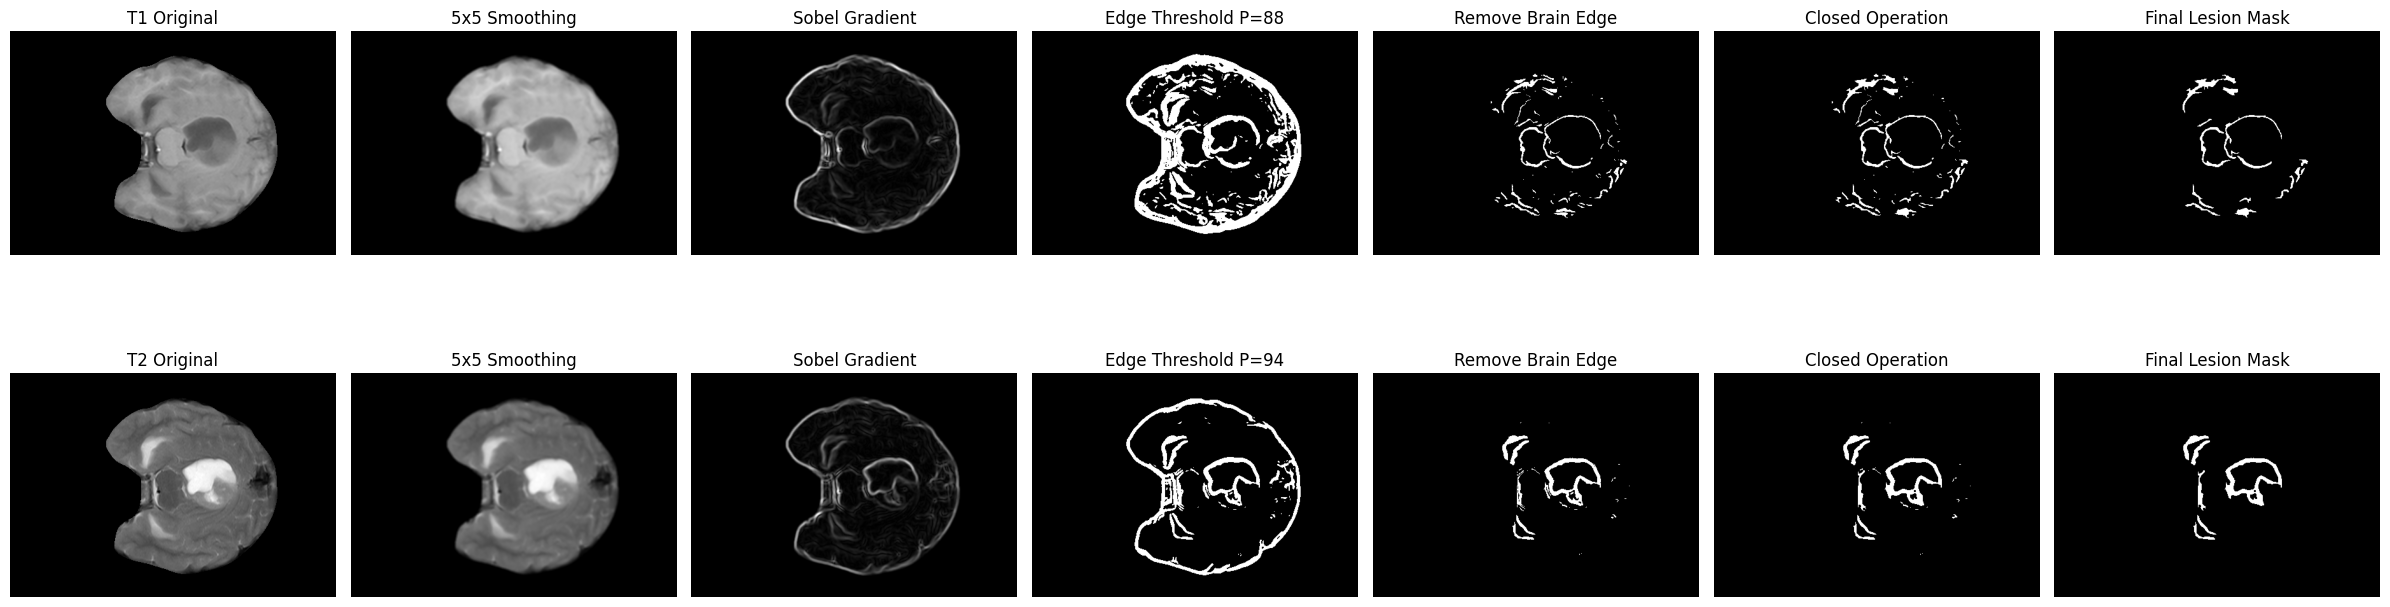

In [83]:
# ==================== Project 1: 边缘检测与病灶分割（去除底部伪线） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=1.5):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=5, intensity_pct=85):
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((8,8)), iterations=erosion_iters)
    intensity_mask = img > np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

# ---------- 修改 postprocess，把闭运算结果也返回 ----------
def postprocess(edge, min_size=50):
    """保留所有面积 >= min_size 的连通域，而非仅最大连通域"""
    closed = ndi.binary_closing(edge, structure=np.ones((3,3)))
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

# ---------- 按连通域 + 坐标过滤 ----------
def select_likely_lesion(mask, img_shape, min_area=50, max_area=5000, bottom_margin=5):
    """
    只保留合理面积、位置不在底部的连通域
    mask: binary闭运算结果
    img_shape: 图像形状
    bottom_margin: 底部阈值，去掉伪线
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    final_mask = np.zeros_like(mask, dtype=bool)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        y_top = stats[i, cv2.CC_STAT_TOP]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        y_bottom = y_top + h

        # 去掉底部伪线
        if y_bottom >= img_shape[0] - bottom_margin:
            continue
        # 保留合理面积
        if min_area <= area <= max_area:
            final_mask[labels == i] = 1
    return final_mask

# ---------- 主 pipeline ----------
def project1_pipeline(img, percentile=94, sigma=2.0,
                      min_size=50, max_size=5000, bottom_margin=5):
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img)
    closed, mask = postprocess(inner_edge, min_size=min_size)
    mask = select_likely_lesion(mask, img.shape, min_area=min_size,
                                max_area=max_size, bottom_margin=bottom_margin)
    return smooth, grad, raw_edge, inner_edge, closed, mask

# ==================== 可视化 — 7 列 ====================
config = {
    'T1': {'percentile': 88, 'sigma':2.0, 'min_size': 50, 'max_size':5000, 'bottom_margin':5},
    'T2': {'percentile': 94, 'sigma':2.0, 'min_size': 50, 'max_size':5000, 'bottom_margin':5},
}

results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    cfg = config[name]
    results[name] = project1_pipeline(img, percentile=cfg['percentile'],
                                      sigma=cfg['sigma'],
                                      min_size=cfg['min_size'],
                                      max_size=cfg['max_size'],
                                      bottom_margin=cfg['bottom_margin'])

fig, axes = plt.subplots(2, 7, figsize=(24, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={config[name]["percentile"]}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain Edge')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Final Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()

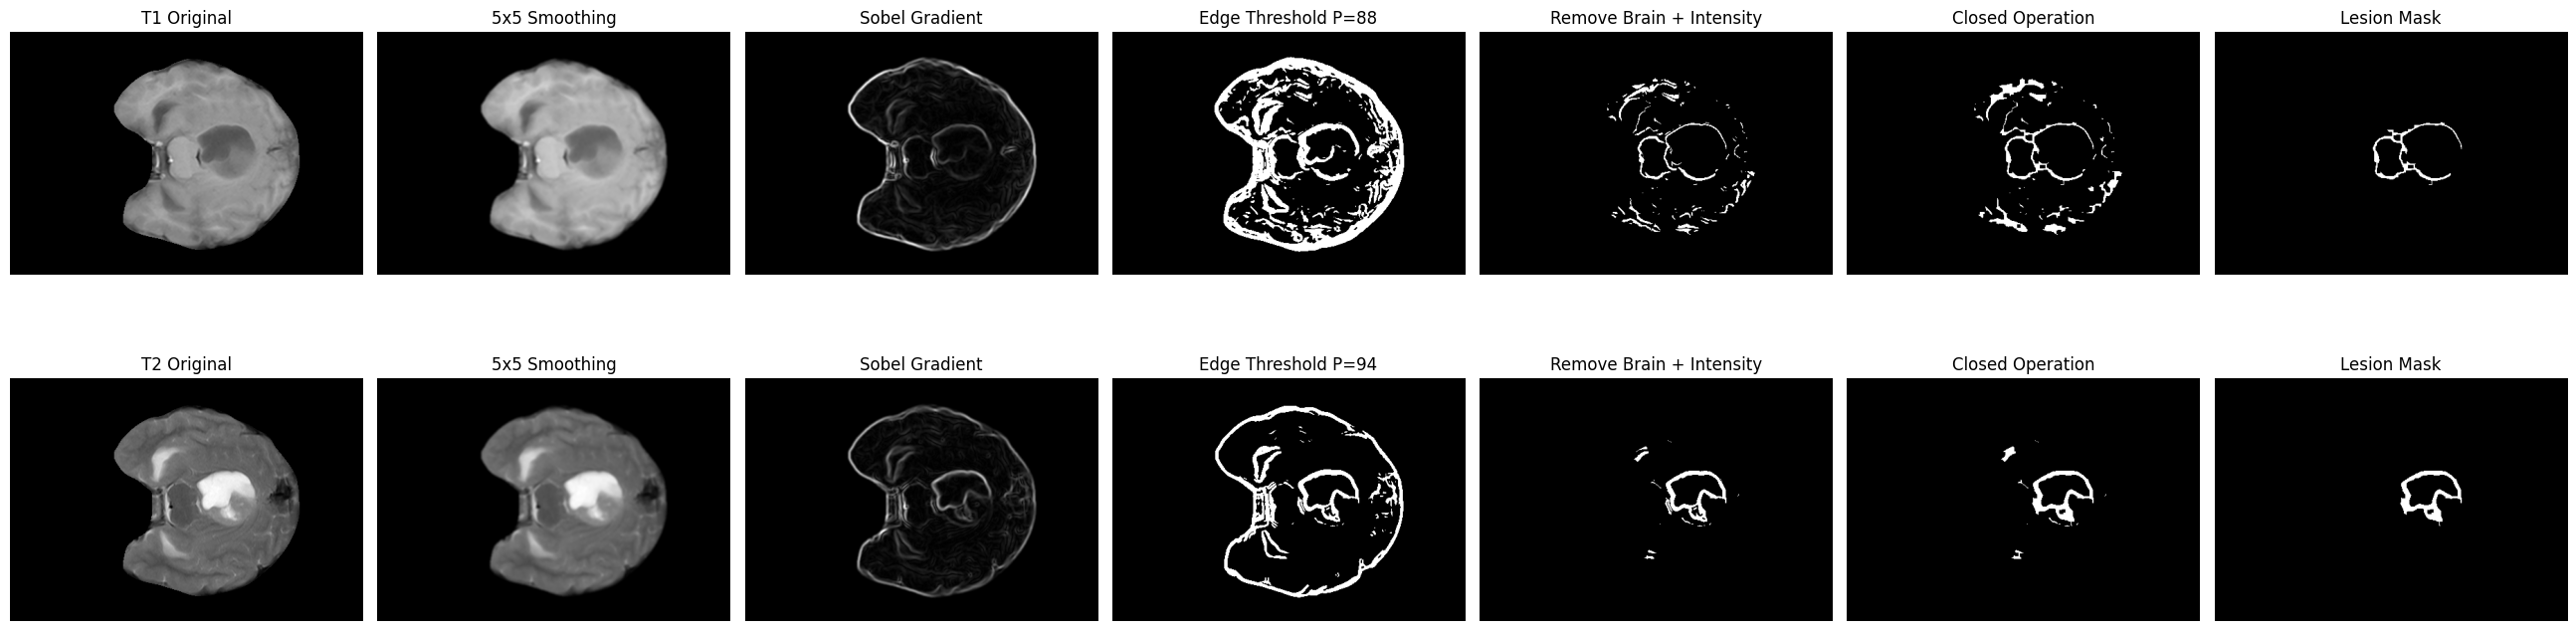

In [81]:
# ==================== Project 1: 边缘检测与病灶分割（最终版优化） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=1.5):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=8, intensity_pct=85):
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((8,8)), iterations=erosion_iters)
    intensity_mask = img > np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

def postprocess(edge, close_size=3, min_size=120):
    se = np.ones((close_size, close_size))
    closed = ndi.binary_closing(edge, structure=se)
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

# ---------- 选择面积最大的病灶连通域 ----------
def select_largest_lesion(closed_edge, min_area=50, max_area=5000):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed_edge.astype(np.uint8), connectivity=8)
    best_label = -1
    max_area_found = -1
    for i in range(1, num_labels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if min_area < area < max_area and area > max_area_found:
            max_area_found = area
            best_label = i
    final_lesion = np.zeros_like(closed_edge, dtype=bool)
    if best_label != -1:
        final_lesion[labels == best_label] = 1
    return final_lesion

# ---------- 主 pipeline ----------
def project1_pipeline(img, percentile=97, sigma=1.5,
                      erosion_iters=8, intensity_pct=85,
                      close_size=3, min_size=120):
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img,
                                   erosion_iters=erosion_iters,
                                   intensity_pct=intensity_pct)
    closed, mask = postprocess(inner_edge, close_size=close_size, min_size=min_size)
    # 挑选最可能的病灶
    mask = select_largest_lesion(mask)
    return smooth, grad, raw_edge, inner_edge, closed, mask

# ==================== 可视化 ====================
config = {
    'T1': {'percentile': 88, 'intensity_pct': 85, 'min_size': 120, 'erosion_iters': 5},
    'T2': {'percentile': 94, 'intensity_pct': 88, 'min_size': 150, 'erosion_iters': 10},
}

results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    cfg = config[name]
    results[name] = project1_pipeline(img, percentile=cfg['percentile'],
                                      erosion_iters=cfg.get('erosion_iters', 15),
                                      intensity_pct=cfg['intensity_pct'],
                                      min_size=cfg['min_size'],
                                      close_size=5)  # 闭运算核增大

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]
    pct = config[name]['percentile']

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={pct}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()

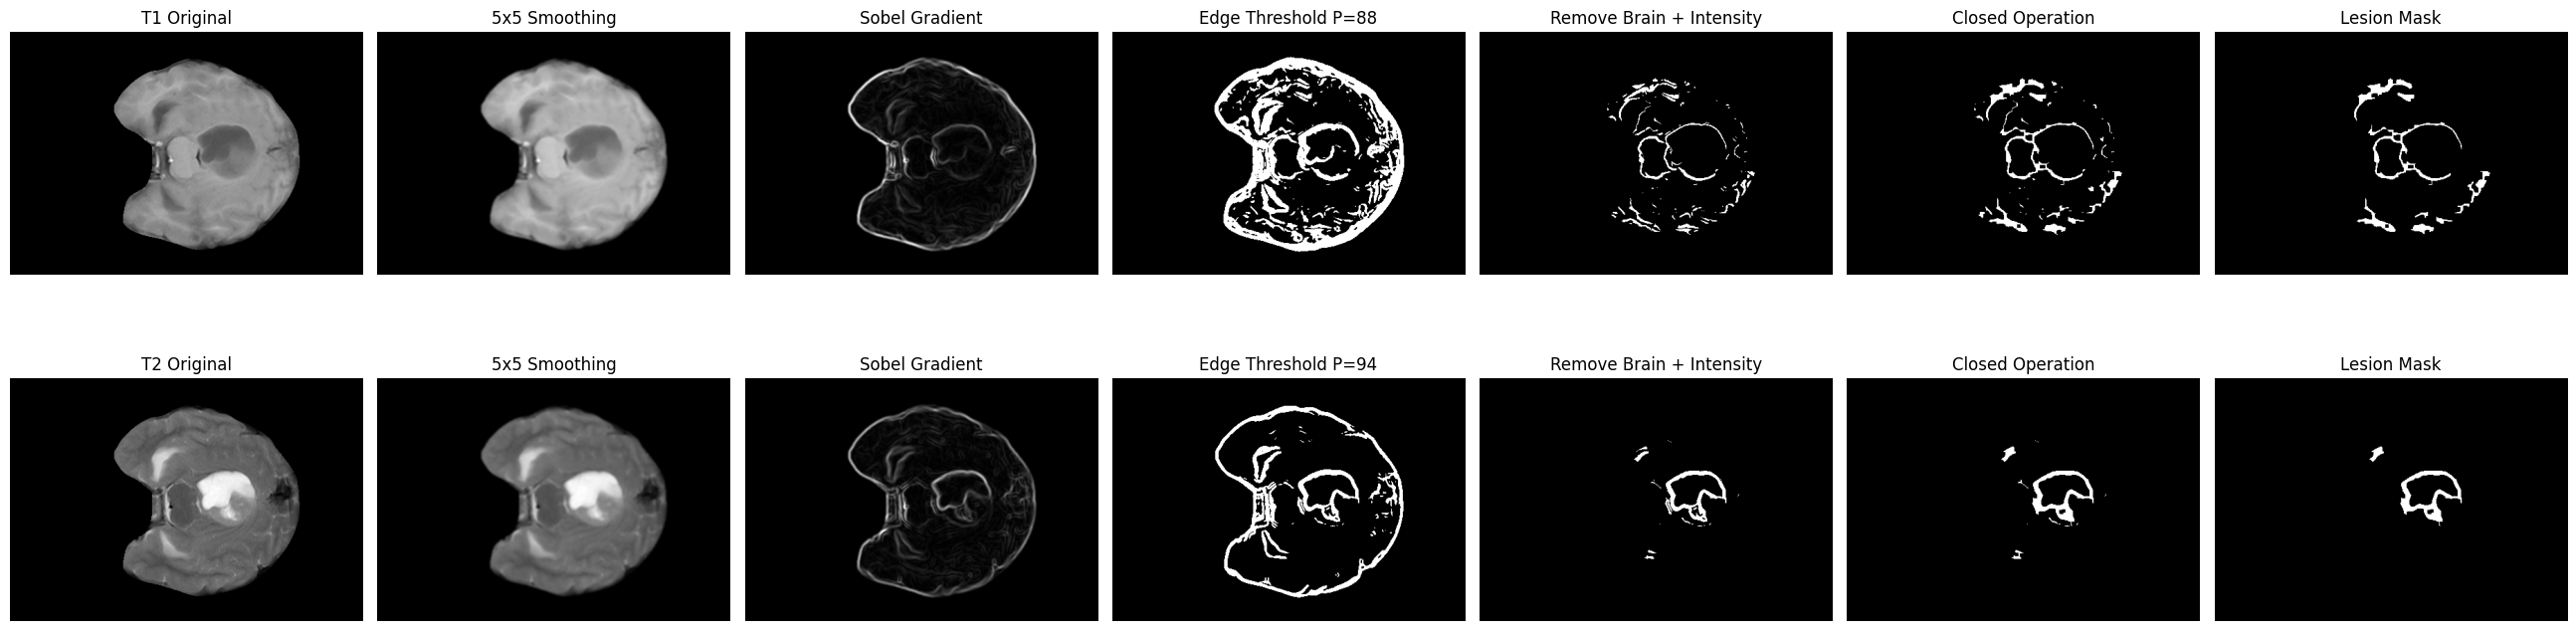

In [82]:
# ==================== Project 1: 边缘检测与病灶分割（去除底部伪线） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=1.5):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=5, intensity_pct=85):
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((8,8)), iterations=erosion_iters)
    intensity_mask = img > np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

def postprocess(edge, close_size=5, min_size=50):
    se = np.ones((close_size, close_size))
    closed = ndi.binary_closing(edge, structure=se)
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

# ---------- 按连通域 + 坐标过滤 ----------
def select_lesion_with_coordinate(mask, img_shape, min_area=50, max_area=5000, bottom_margin=5):
    """
    mask: 二值闭运算结果
    bottom_margin: 去掉底部伪线的纵坐标阈值
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    final_mask = np.zeros_like(mask, dtype=bool)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        y_top = stats[i, cv2.CC_STAT_TOP]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        y_bottom = y_top + h
        # 去掉最下面的伪线
        if y_bottom >= img_shape[0] - bottom_margin:
            continue
        # 保留合理面积
        if min_area < area < max_area:
            final_mask[labels == i] = 1
    return final_mask

# ---------- 主 pipeline ----------
def project1_pipeline(img, percentile=97, sigma=1.5,
                      erosion_iters=5, intensity_pct=85,
                      close_size=5, min_size=50):
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img,
                                   erosion_iters=erosion_iters,
                                   intensity_pct=intensity_pct)
    closed, mask = postprocess(inner_edge, close_size=close_size, min_size=min_size)
    mask = select_lesion_with_coordinate(mask, img.shape)
    return smooth, grad, raw_edge, inner_edge, closed, mask

# ==================== 可视化 ====================
config = {
    'T1': {'percentile': 88, 'intensity_pct': 85, 'min_size': 50, 'erosion_iters': 5},
    'T2': {'percentile': 94, 'intensity_pct': 88, 'min_size': 150, 'erosion_iters': 10},
}

results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    cfg = config[name]
    results[name] = project1_pipeline(img, percentile=cfg['percentile'],
                                      erosion_iters=cfg.get('erosion_iters', 15),
                                      intensity_pct=cfg['intensity_pct'],
                                      min_size=cfg['min_size'],
                                      close_size=5)

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]
    pct = config[name]['percentile']

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={pct}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()

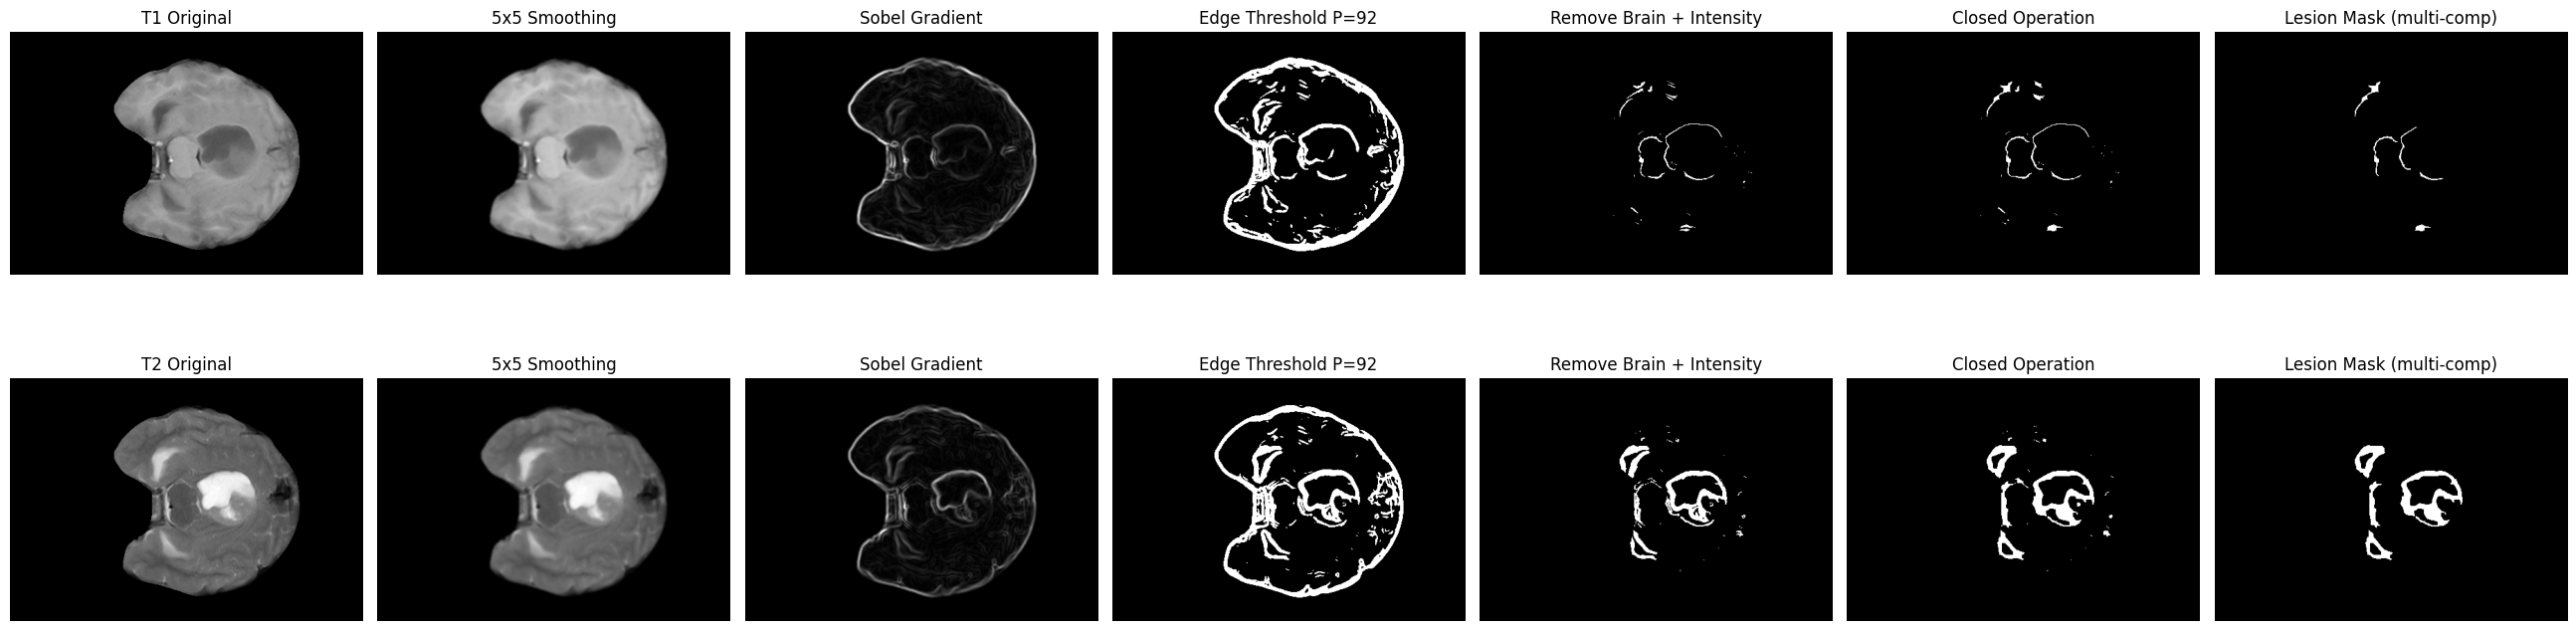

In [49]:
# ==================== Project 1: 边缘检测与病灶分割（改进版） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=2.0):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    """支持 sobel / scharr 两种算子"""
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=2.0):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

# ---------- 核心 pipeline 步骤 ----------
def remove_brain_edge(edge, img, erosion_iters=6, intensity_pct=80):
    """
    1. 腐蚀脑掩码去除颅骨边缘
    2. 叠加原图强度约束：只保留高亮区域的边缘（病灶在 T2 中为高信号）
    """
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((5,5)), iterations=erosion_iters)
    # 强度约束：只保留原图顶部 (100-intensity_pct)% 亮度的区域
    intensity_mask = img > np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

def postprocess(edge, min_size=50):
    """闭运算连接断裂边缘，保留所有面积 >= min_size 的连通域"""
    closed = ndi.binary_closing(edge, structure=np.ones((5,5)))
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

def project1_pipeline(img, percentile=95, sigma=1.5, operator='sobel',
                      erosion_iters=9, intensity_pct=90, min_size=80):
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth, operator=operator)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img,
                                   erosion_iters=erosion_iters,
                                   intensity_pct=intensity_pct)
    closed, mask = postprocess(inner_edge, min_size=min_size)
    return smooth, grad, raw_edge, inner_edge, closed, mask


# ==================== 可视化 — 7 列完整流程 ====================
percentile = 92
results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    results[name] = project1_pipeline(img, percentile=percentile)

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={percentile}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask (multi-comp)')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()


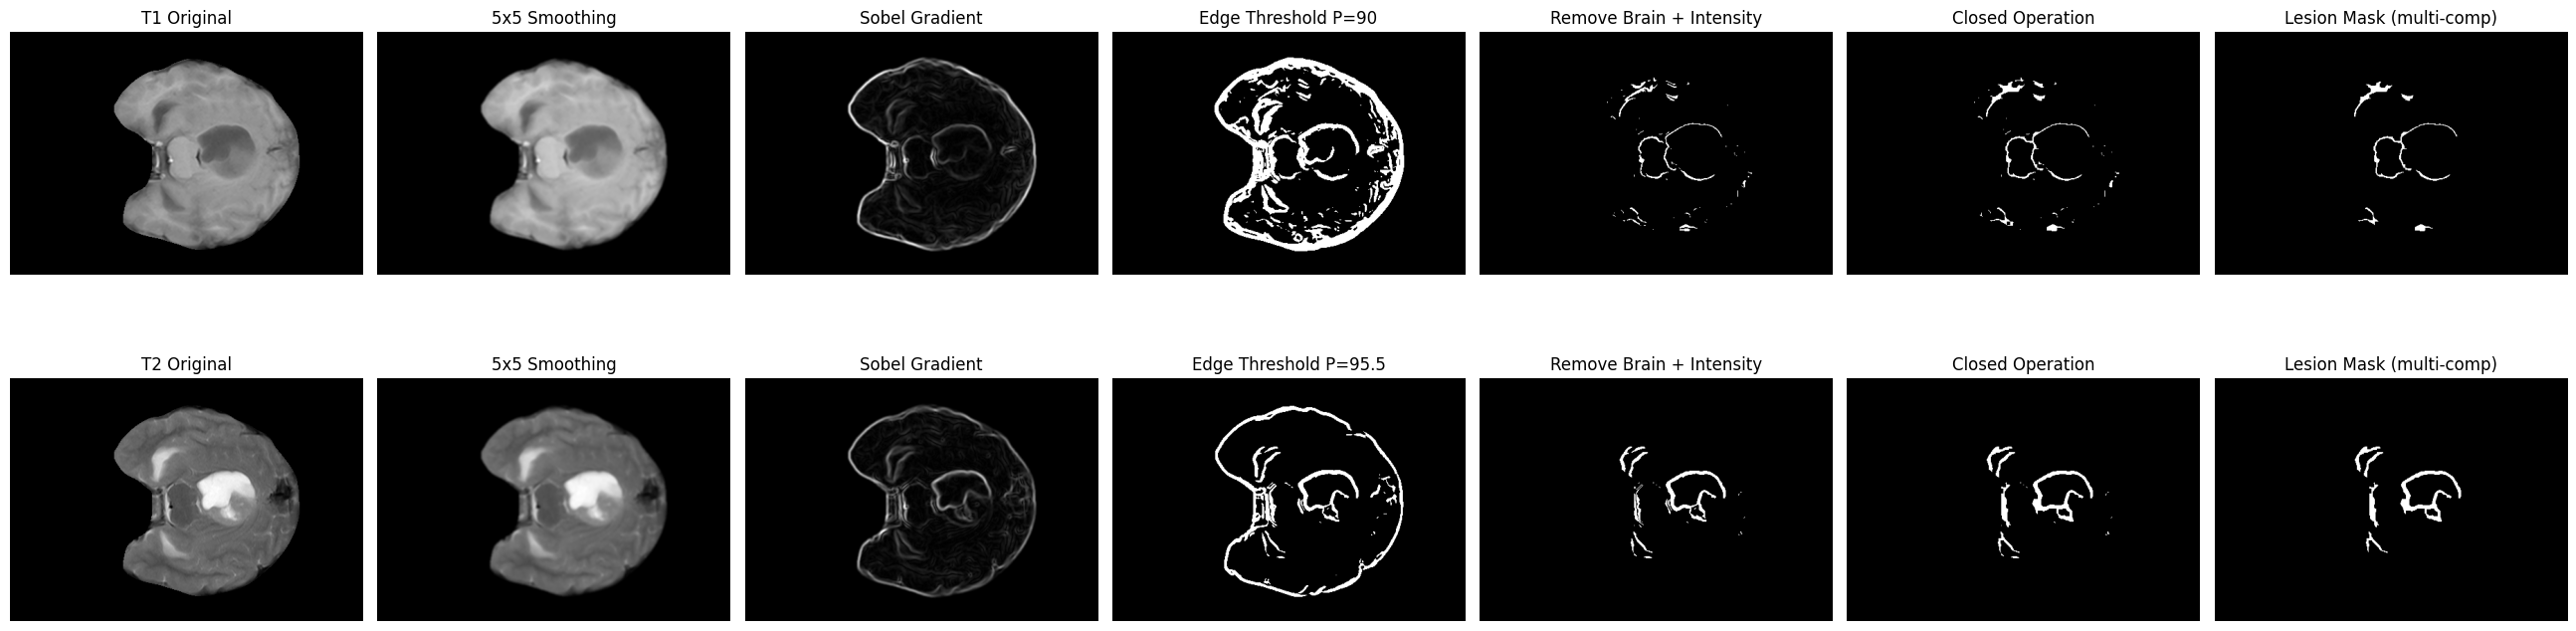

In [50]:
# ==================== 可视化 — T1/T2 各自使用不同阈值 ====================
# T1 对比度通常更低，用更宽松的阈值；T2 病灶更亮，可以用更严格的阈值
config = {
    'T1': {'percentile': 90},   # 宽松一些，避免漏掉低对比度病灶
    'T2': {'percentile': 95.5},   # 严格一些，抑制大量正常组织边缘
}

results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    results[name] = project1_pipeline(img, percentile=config[name]['percentile'])

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]
    pct = config[name]['percentile']

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={pct}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask (multi-comp)')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()


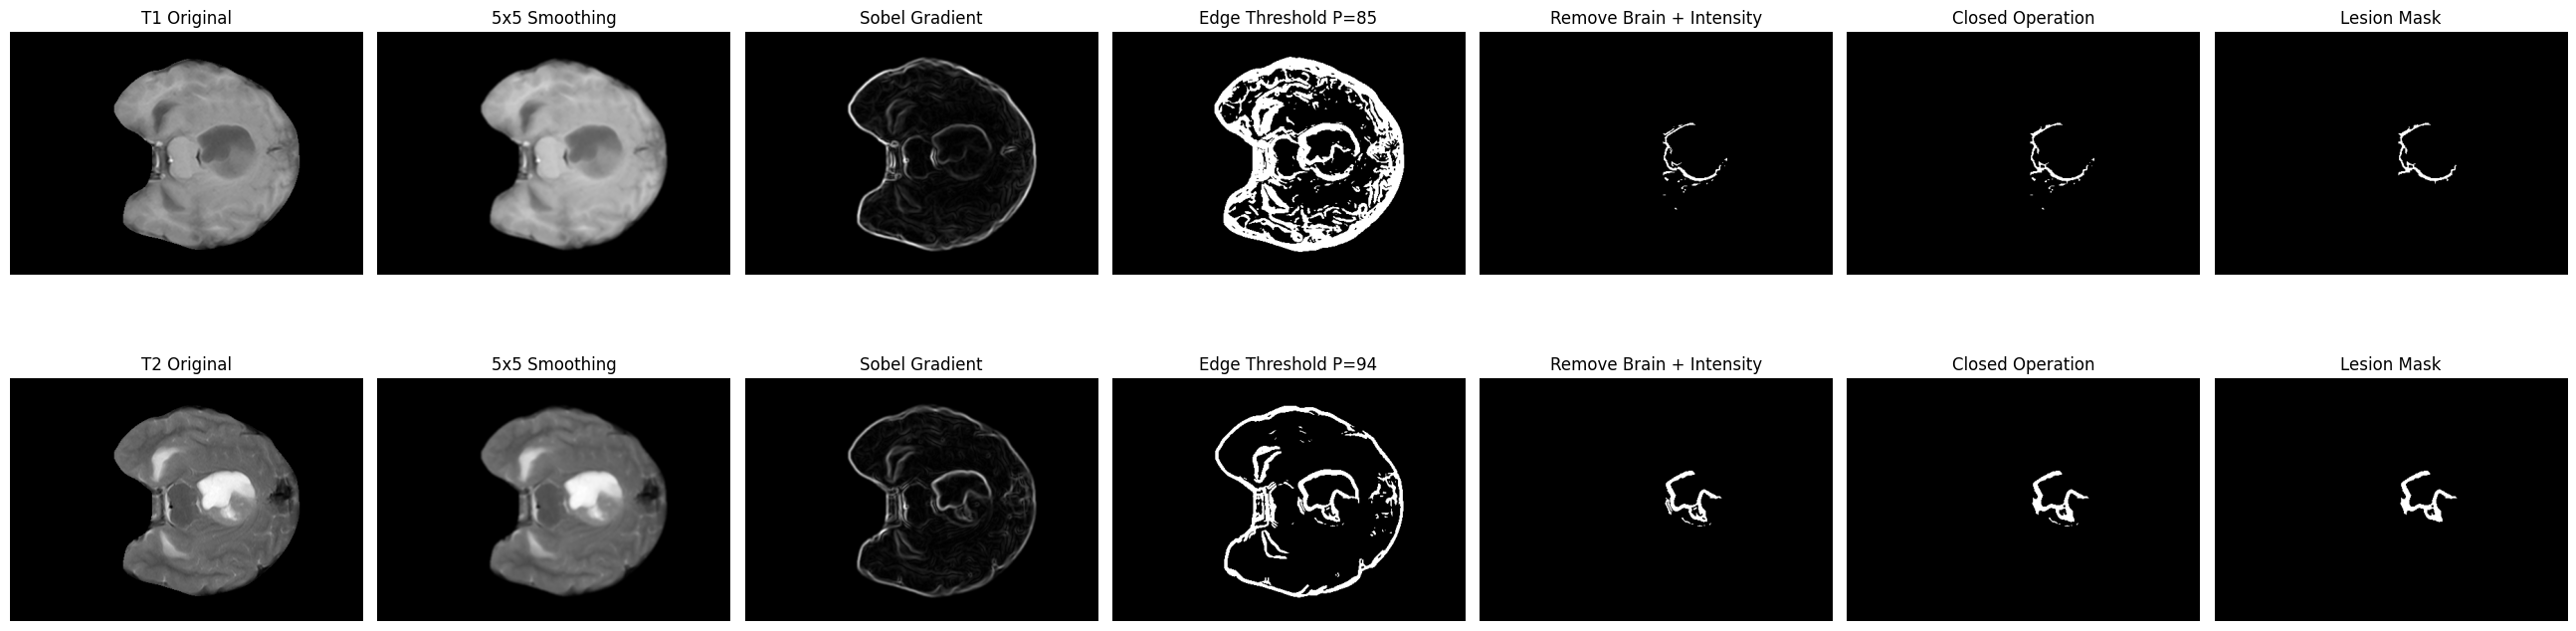

In [62]:
# ==================== Project 1: 边缘检测与病灶分割（最终版） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=1.5):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=8, intensity_pct=85):
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((8,8)), iterations=erosion_iters)
    intensity_mask = img > np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

def postprocess(edge, close_size=3, min_size=120):
    se = np.ones((close_size, close_size))
    closed = ndi.binary_closing(edge, structure=se)
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

# ---------- 主 pipeline ----------
def project1_pipeline(img, percentile=97, sigma=1.5,
                      erosion_iters=15, intensity_pct=85,
                      close_size=3, min_size=120):
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img,
                                   erosion_iters=erosion_iters,
                                   intensity_pct=intensity_pct)
    closed, mask = postprocess(inner_edge, close_size=close_size, min_size=min_size)
    return smooth, grad, raw_edge, inner_edge, closed, mask


# ==================== 可视化 ====================
config = {
    'T1': {'percentile': 85, 'intensity_pct': 85, 'min_size': 100},
    'T2': {'percentile': 94, 'intensity_pct': 88, 'min_size': 150},
}

results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    cfg = config[name]
    results[name] = project1_pipeline(img, percentile=cfg['percentile'],
                                      intensity_pct=cfg['intensity_pct'],
                                      min_size=cfg['min_size'])

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]
    pct = config[name]['percentile']

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('5x5 Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={pct}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()


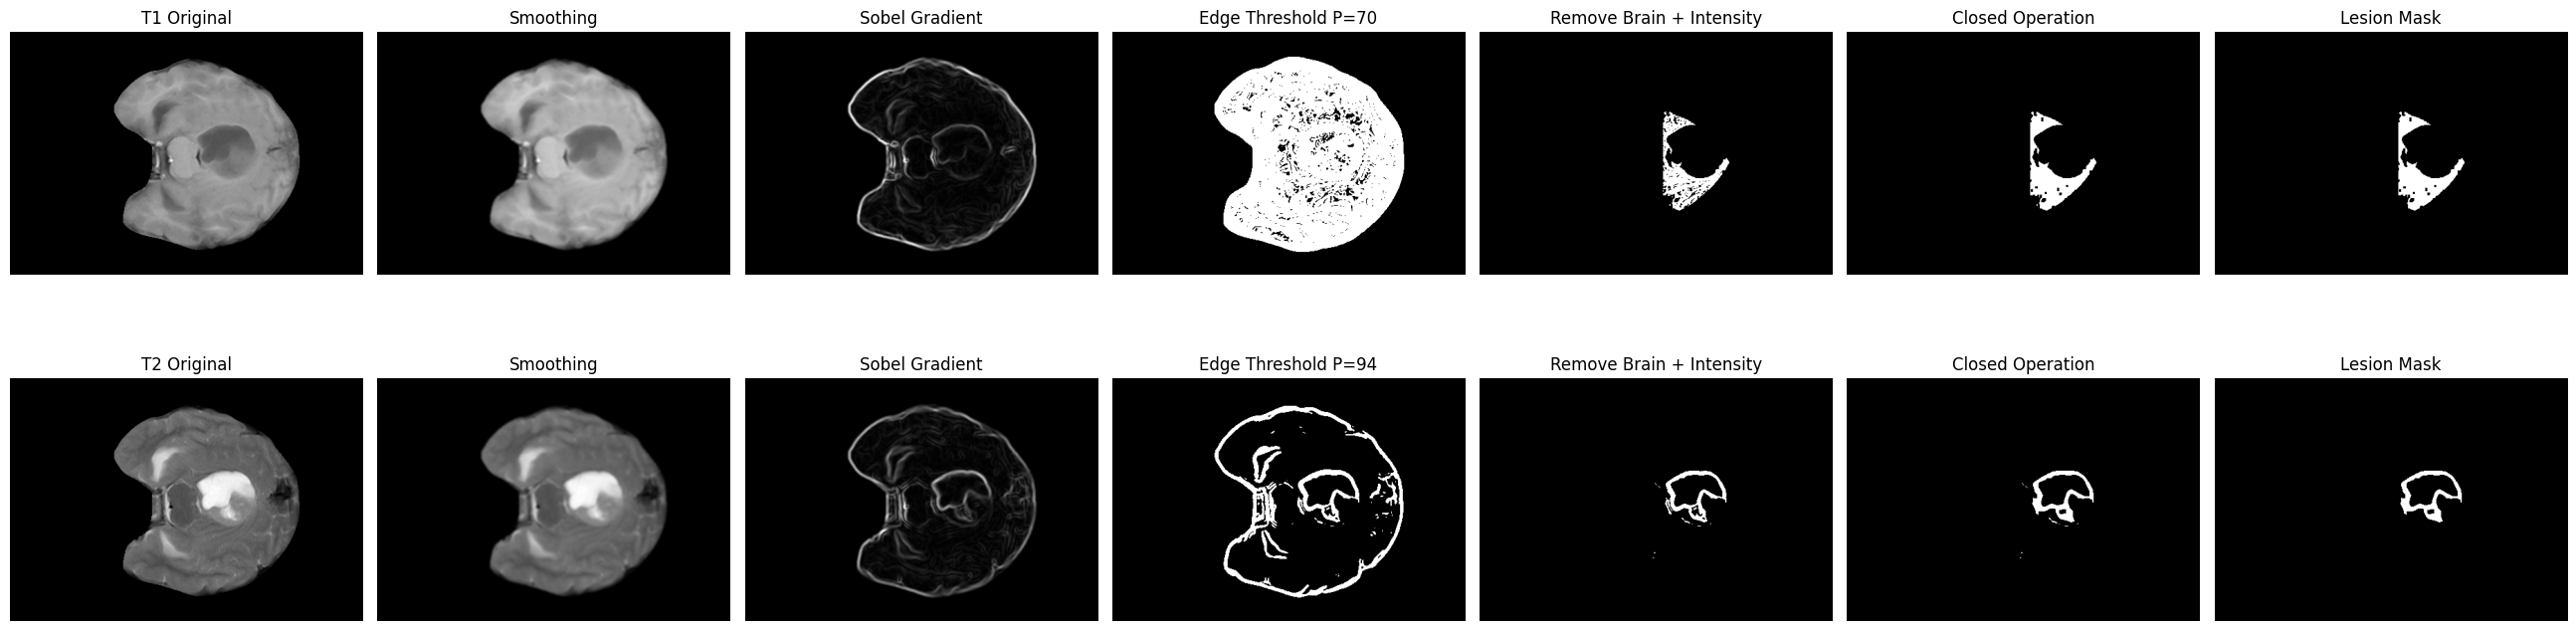

In [105]:
# ==================== Project 1: 边缘检测与病灶分割（可调参版） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=1.5):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=8, intensity_pct=85):
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((8,8)), iterations=erosion_iters)
    intensity_mask = img > np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

def postprocess(edge, close_size=3, min_size=120):
    se = np.ones((close_size, close_size))
    closed = ndi.binary_closing(edge, structure=se)
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

# ---------- pipeline 支持调参 ----------
def project1_pipeline(img, percentile=94, sigma=2.0,
                      erosion_iters=8, intensity_pct=85,
                      close_size=3, min_size=50):
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    T = np.percentile(grad, percentile)
    raw_edge = grad > T
    inner_edge = remove_brain_edge(raw_edge, img,
                                   erosion_iters=erosion_iters,
                                   intensity_pct=intensity_pct)
    closed, mask = postprocess(inner_edge, close_size=close_size, min_size=min_size)
    return smooth, grad, raw_edge, inner_edge, closed, mask

# ==================== 可调参数配置 ====================
config = {
    'T1': {
        'percentile': 70,
        'sigma': 1.5,
        'erosion_iters': 15,
        'intensity_pct': 85,
        'close_size': 3,
        'min_size': 120
    },
    'T2': {
        'percentile': 94,
        'sigma': 2.0,
        'erosion_iters': 12,
        'intensity_pct': 88,
        'close_size': 5,
        'min_size': 50
    }
}

# ==================== 执行 pipeline 并可视化 ====================
results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    cfg = config[name]
    results[name] = project1_pipeline(img,
                                      percentile=cfg['percentile'],
                                      sigma=cfg['sigma'],
                                      erosion_iters=cfg['erosion_iters'],
                                      intensity_pct=cfg['intensity_pct'],
                                      close_size=cfg['close_size'],
                                      min_size=cfg['min_size'])

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    axes[row, 3].set_title(f'Edge Threshold P={config[name]["percentile"]}')

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()

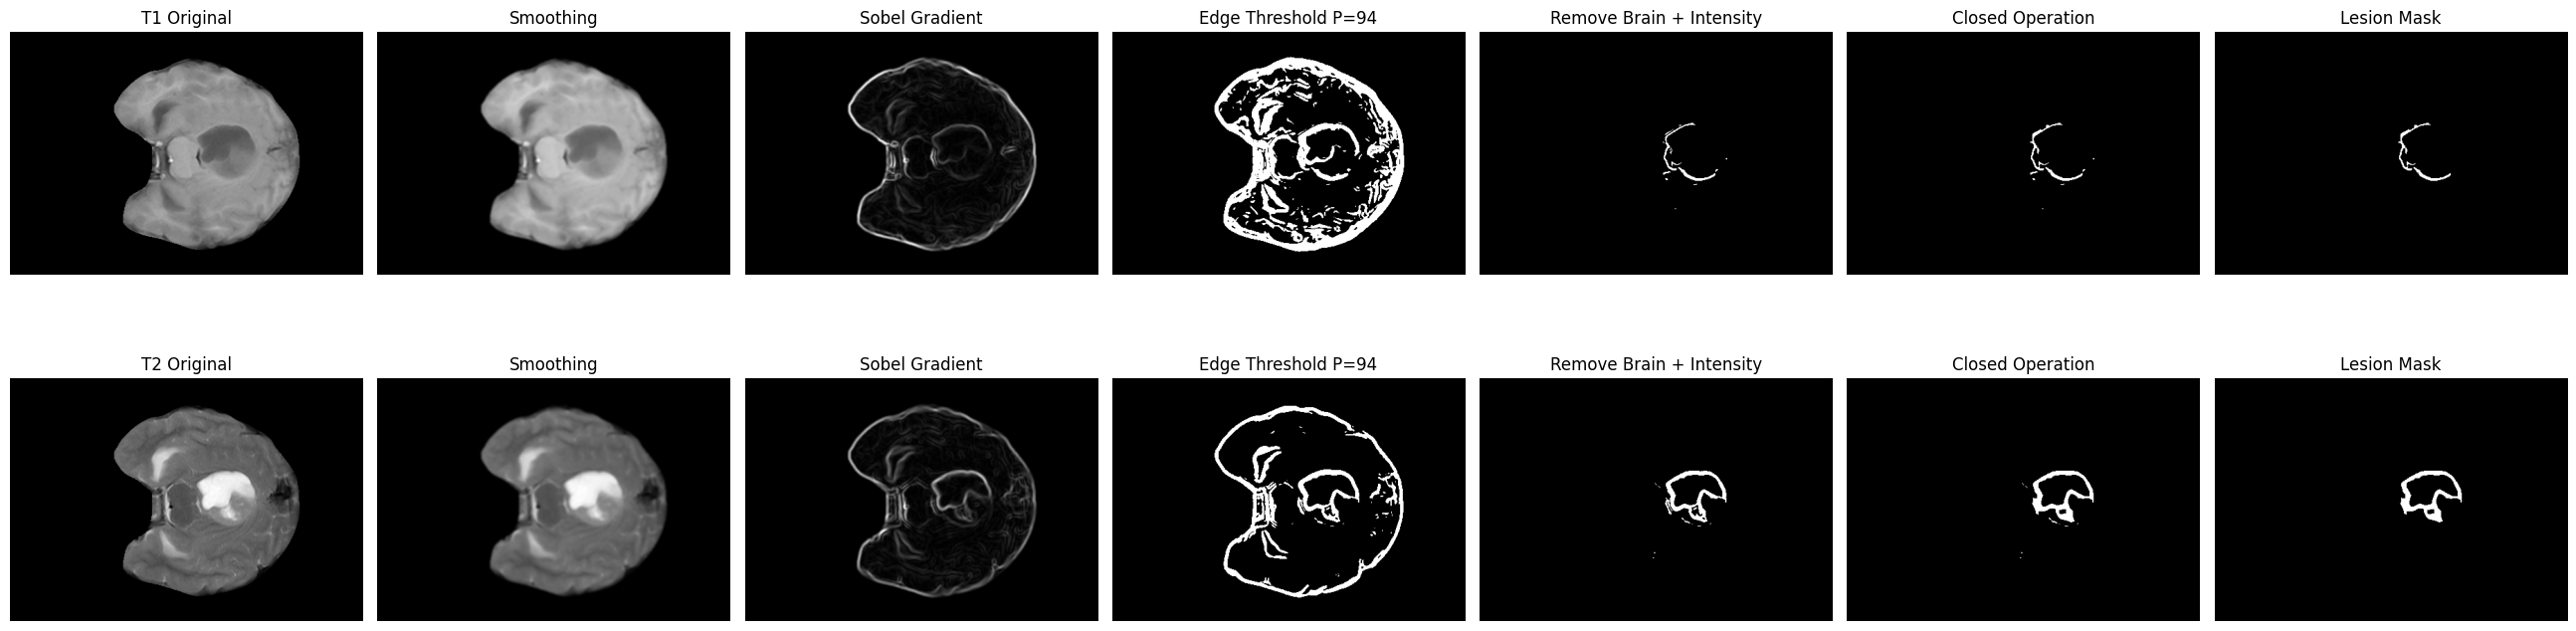

In [114]:
# ==================== Project 1: 边缘检测与病灶分割（T1 用绝对阈值） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=1.5):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=8, intensity_pct=85):
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((8,8)), iterations=erosion_iters)
    intensity_mask = img > np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

def postprocess(edge, close_size=3, min_size=120):
    se = np.ones((close_size, close_size))
    closed = ndi.binary_closing(edge, structure=se)
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

# ---------- pipeline 支持调参 ----------
def project1_pipeline(img, use_absolute_threshold=False, threshold=70, percentile=94,
                      sigma=2.0, erosion_iters=8, intensity_pct=85,
                      close_size=3, min_size=50):
    """
    use_absolute_threshold: True -> 使用绝对值阈值 threshold
                            False -> 使用百分位数阈值 percentile
    """
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    
    if use_absolute_threshold:
        raw_edge = grad > threshold
    else:
        T = np.percentile(grad, percentile)
        raw_edge = grad > T

    inner_edge = remove_brain_edge(raw_edge, img,
                                   erosion_iters=erosion_iters,
                                   intensity_pct=intensity_pct)
    closed, mask = postprocess(inner_edge, close_size=close_size, min_size=min_size)
    return smooth, grad, raw_edge, inner_edge, closed, mask

# ==================== 可调参数配置 ====================
config = {
    'T1': {
        'use_absolute_threshold': True,
        'threshold': 70,
        'sigma': 1.5,
        'erosion_iters': 15,
        'intensity_pct': 85,
        'close_size': 3,
        'min_size': 120
    },
    'T2': {
        'use_absolute_threshold': False,
        'percentile': 94,
        'sigma': 2.0,
        'erosion_iters': 12,
        'intensity_pct': 88,
        'close_size': 5,
        'min_size': 50
    }
}

# ==================== 执行 pipeline 并可视化 ====================
results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    cfg = config[name]
    results[name] = project1_pipeline(img,
                                      use_absolute_threshold=cfg.get('use_absolute_threshold', False),
                                      threshold=cfg.get('threshold', 70),
                                      percentile=cfg.get('percentile', 94),
                                      sigma=cfg['sigma'],
                                      erosion_iters=cfg['erosion_iters'],
                                      intensity_pct=cfg['intensity_pct'],
                                      close_size=cfg['close_size'],
                                      min_size=cfg['min_size'])

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    title_str = f'Edge Threshold {"T="+str(cfg["threshold"]) if cfg.get("use_absolute_threshold") else "P="+str(cfg.get("percentile"))}'
    axes[row, 3].set_title(title_str)

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()

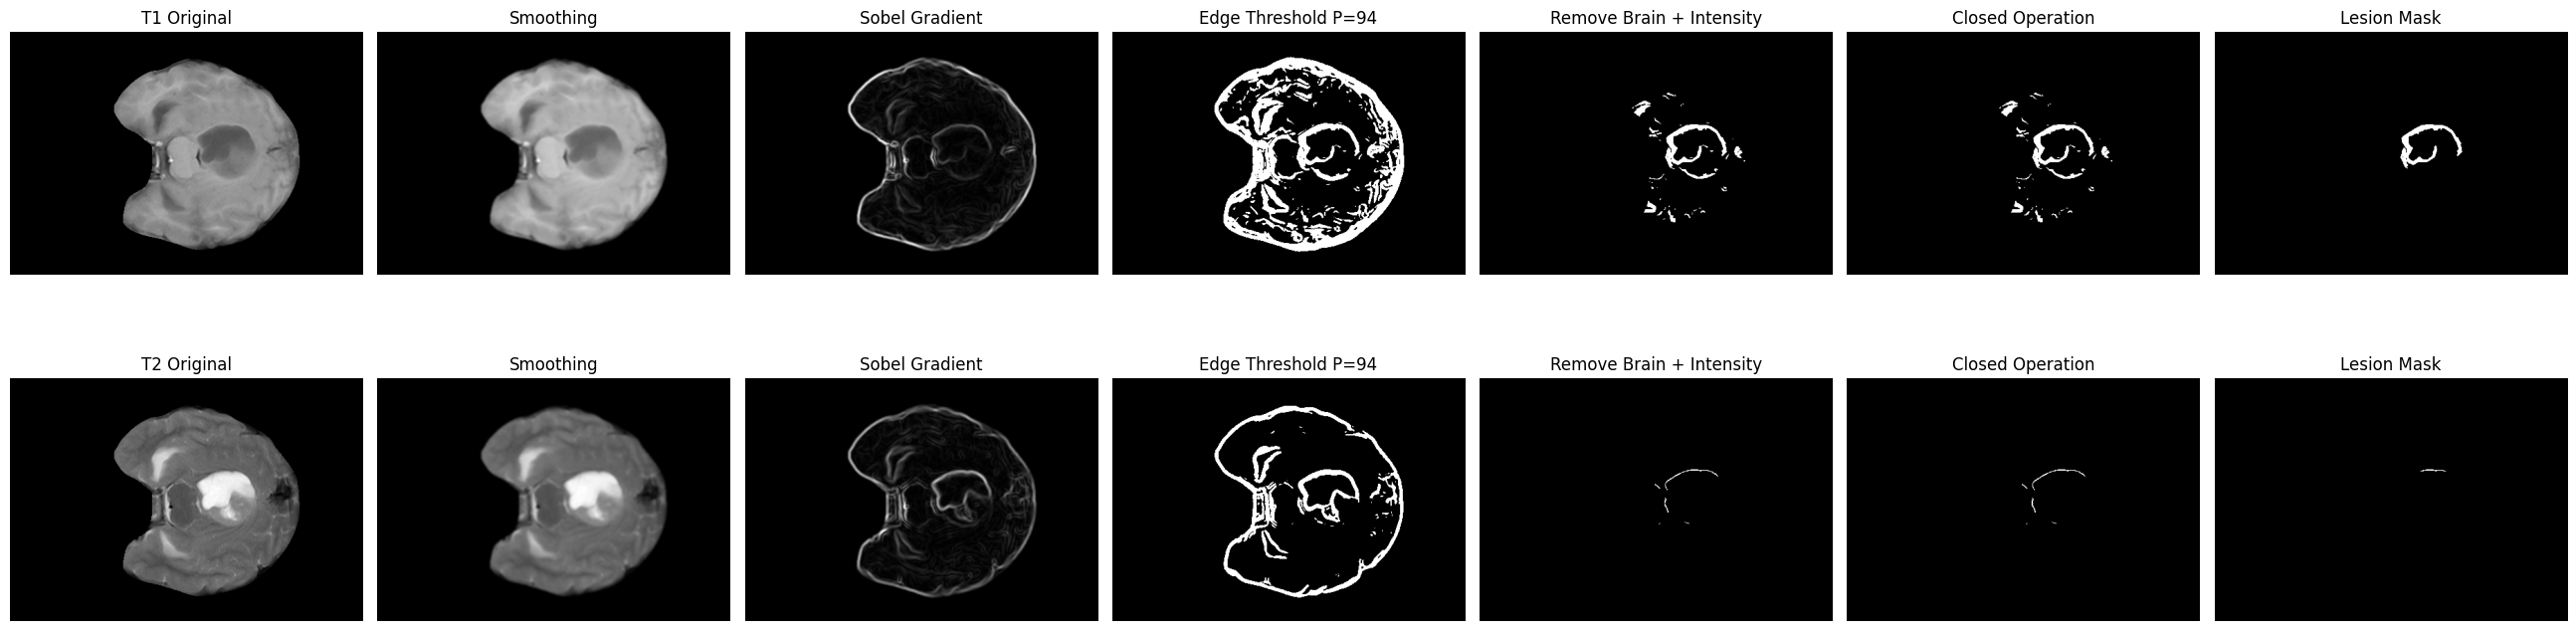

In [155]:
# ==================== Project 1: 边缘检测与病灶分割（完全可调参版） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=1.5):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=8, intensity_pct=85):
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((8,8)), iterations=erosion_iters)
    intensity_mask = img < np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

def postprocess(edge, close_size=3, min_size=120):
    se = np.ones((close_size, close_size))
    closed = ndi.binary_closing(edge, structure=se)
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

# ---------- 完全可调参数 pipeline ----------
def project1_pipeline(img, use_absolute_threshold=False, threshold=70, percentile=94,
                      sigma=2.0, erosion_iters=8, intensity_pct=85,
                      close_size=3, min_size=50):
    """
    use_absolute_threshold: True -> 使用绝对值阈值 threshold
                            False -> 使用百分位数阈值 percentile
    """
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    
    if use_absolute_threshold:
        raw_edge = grad > threshold
    else:
        T = np.percentile(grad, percentile)
        raw_edge = grad > T

    inner_edge = remove_brain_edge(raw_edge, img,
                                   erosion_iters=erosion_iters,
                                   intensity_pct=intensity_pct)
    closed, mask = postprocess(inner_edge, close_size=close_size, min_size=min_size)
    return smooth, grad, raw_edge, inner_edge, closed, mask

# ==================== 完全可调 config ====================
config = {
    'T1': {
        'use_absolute_threshold': True,
        'threshold': 70,        # 绝对值阈值
        'percentile': 85,       # 百分位阈值（备用）
        'sigma': 1.5,
        'erosion_iters': 10,
        'intensity_pct': 90,
        'close_size': 1,
        'min_size': 300
    },
    'T2': {
        'use_absolute_threshold': False,
        'threshold': 70,        # 绝对值阈值（备用）
        'percentile': 94,       # 百分位阈值
        'sigma': 2.0,
        'erosion_iters': 12,
        'intensity_pct': 88,
        'close_size': 5,
        'min_size': 50
    }
}

# ==================== 执行 pipeline 并可视化 ====================
results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    cfg = config[name]
    results[name] = project1_pipeline(img,
                                      use_absolute_threshold=cfg.get('use_absolute_threshold', False),
                                      threshold=cfg.get('threshold', 70),
                                      percentile=cfg.get('percentile', 94),
                                      sigma=cfg['sigma'],
                                      erosion_iters=cfg['erosion_iters'],
                                      intensity_pct=cfg['intensity_pct'],
                                      close_size=cfg['close_size'],
                                      min_size=cfg['min_size'])

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    title_str = f'Edge Threshold {"T="+str(cfg["threshold"]) if cfg.get("use_absolute_threshold") else "P="+str(cfg.get("percentile"))}'
    axes[row, 3].set_title(title_str)

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')
fig.tight_layout()
plt.show()

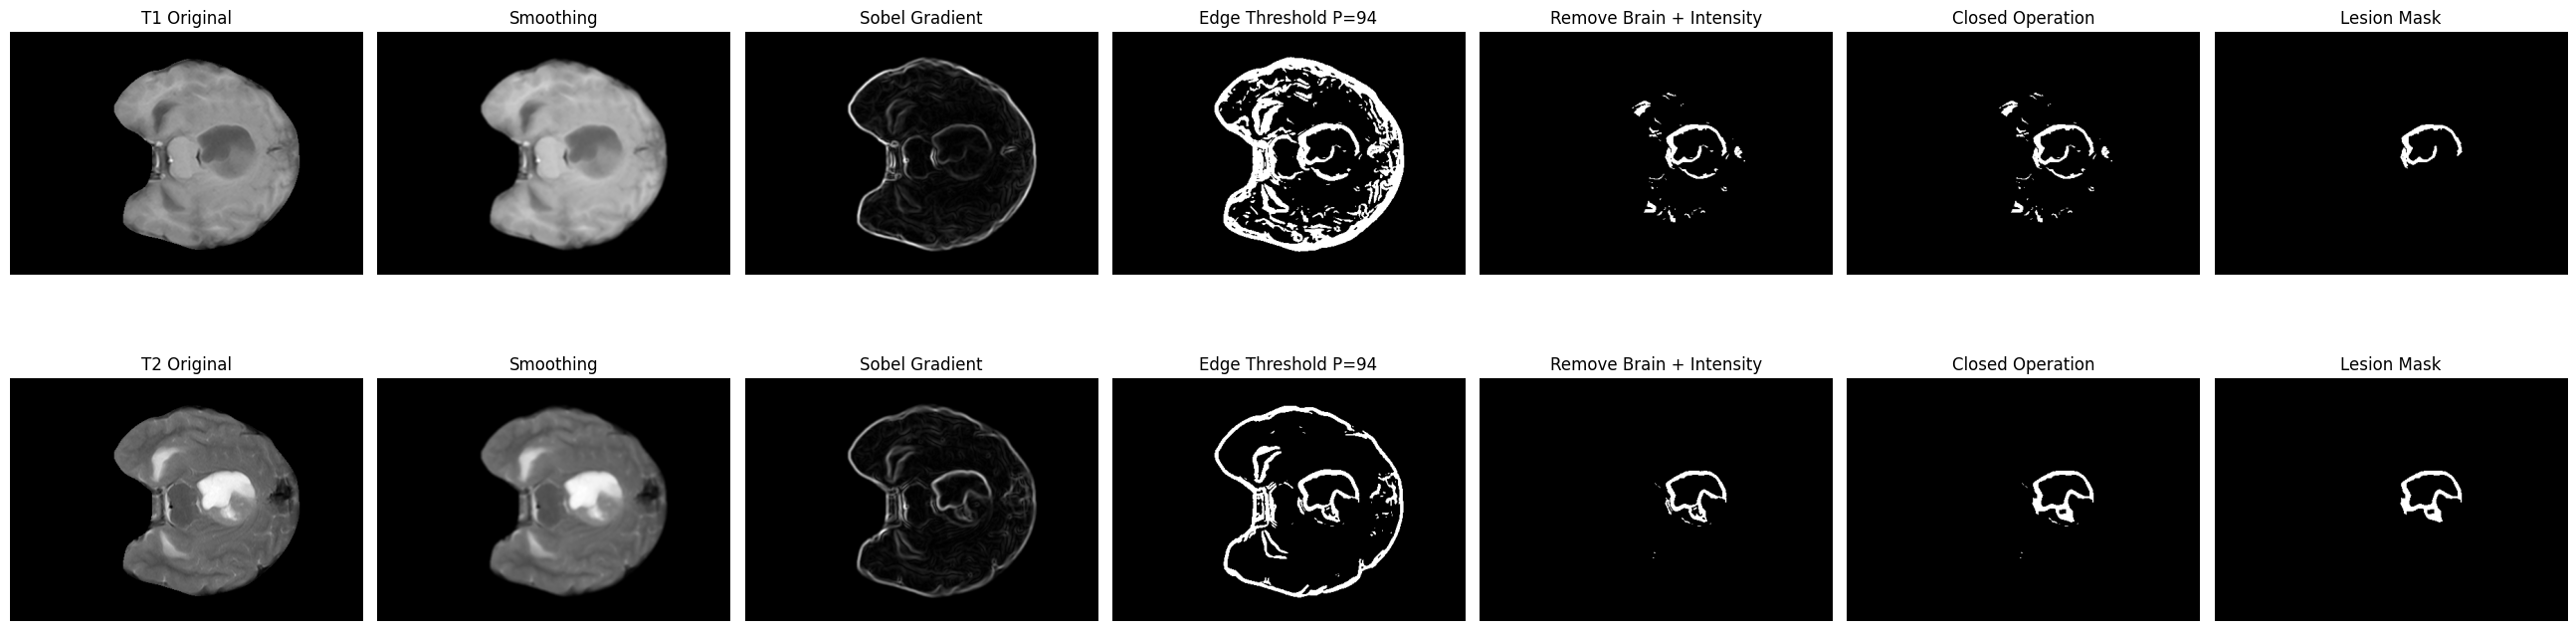

In [156]:
# ==================== Project 1: 边缘检测与病灶分割（完全可调参版） ====================
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('.')
T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ---------- 工具函数 ----------
def gaussian_kernel(size=5, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / kernel.sum()

def sobel_gradients(img, operator='sobel'):
    if operator == 'scharr':
        gx = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]], dtype=float) / 16
        gy = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]], dtype=float) / 16
    else:
        gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
        gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float)
    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')
    return np.hypot(grad_x, grad_y), grad_x, grad_y

def preprocess(img, sigma=1.5):
    kernel = gaussian_kernel(5, sigma=sigma)
    return ndi.convolve(img, kernel, mode='reflect')

def brain_mask(img):
    thresh = np.percentile(img, 5) + 0.1 * (np.percentile(img, 99) - np.percentile(img, 5))
    mask = img > thresh
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argmax(sizes)
    brain = labeled == largest
    brain = ndi.binary_fill_holes(brain)
    return brain

def remove_brain_edge(edge, img, erosion_iters=8, intensity_pct=85, mode='lt'):
    """
    mode: 'lt' -> intensity_mask = img < np.percentile(img, intensity_pct)
          'gt' -> intensity_mask = img > np.percentile(img, intensity_pct)
    """
    mask = brain_mask(img)
    inner = ndi.binary_erosion(mask, structure=np.ones((8,8)), iterations=erosion_iters)
    if mode == 'lt':
        intensity_mask = img < np.percentile(img, intensity_pct)
    else:
        intensity_mask = img > np.percentile(img, intensity_pct)
    return edge & inner & intensity_mask

def postprocess(edge, close_size=3, min_size=120):
    se = np.ones((close_size, close_size))
    closed = ndi.binary_closing(edge, structure=se)
    labeled, num = ndi.label(closed)
    if num == 0:
        return closed, closed
    sizes = np.bincount(labeled.ravel())
    keep_labels = np.where(sizes[1:] >= min_size)[0] + 1
    mask = np.isin(labeled, keep_labels)
    return closed, mask

# ---------- 完全可调参数 pipeline ----------
def project1_pipeline(img, use_absolute_threshold=False, threshold=70, percentile=94,
                      sigma=2.0, erosion_iters=8, intensity_pct=85,
                      close_size=3, min_size=50, mode='lt'):
    """
    use_absolute_threshold: True -> 使用绝对值阈值 threshold
                            False -> 使用百分位数阈值 percentile
    mode: 'lt' -> intensity_mask = img < percentile
          'gt' -> intensity_mask = img > percentile
    """
    smooth = preprocess(img, sigma=sigma)
    grad, gx, gy = sobel_gradients(smooth)
    
    if use_absolute_threshold:
        raw_edge = grad > threshold
    else:
        T = np.percentile(grad, percentile)
        raw_edge = grad > T

    inner_edge = remove_brain_edge(raw_edge, img,
                                   erosion_iters=erosion_iters,
                                   intensity_pct=intensity_pct,
                                   mode=mode)
    closed, mask = postprocess(inner_edge, close_size=close_size, min_size=min_size)
    return smooth, grad, raw_edge, inner_edge, closed, mask

# ==================== 完全可调 config ====================
config = {
    'T1': {
        'use_absolute_threshold': True,
        'threshold': 70,
        'percentile': 85,
        'sigma': 1.5,
        'erosion_iters': 10,
        'intensity_pct': 90,
        'close_size': 1,
        'min_size': 300,
        'mode': 'lt'  # T1 用小于
    },
    'T2': {
        'use_absolute_threshold': False,
        'threshold': 70,
        'percentile': 94,
        'sigma': 2.0,
        'erosion_iters': 12,
        'intensity_pct': 88,
        'close_size': 5,
        'min_size': 50,
        'mode': 'gt'  # T2 用大于
    }
}

# ==================== 执行 pipeline 并可视化 ====================
results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    cfg = config[name]
    results[name] = project1_pipeline(img,
                                      use_absolute_threshold=cfg.get('use_absolute_threshold', False),
                                      threshold=cfg.get('threshold', 70),
                                      percentile=cfg.get('percentile', 94),
                                      sigma=cfg['sigma'],
                                      erosion_iters=cfg['erosion_iters'],
                                      intensity_pct=cfg['intensity_pct'],
                                      close_size=cfg['close_size'],
                                      min_size=cfg['min_size'],
                                      mode=cfg.get('mode', 'lt'))

fig, axes = plt.subplots(2, 7, figsize=(26, 8))
for row, name in enumerate(['T1', 'T2']):
    smooth, grad, raw_edge, inner_edge, closed, mask = results[name]

    axes[row, 0].imshow(eval(name), cmap='gray')
    axes[row, 0].set_title(f'{name} Original')

    axes[row, 1].imshow(smooth, cmap='gray')
    axes[row, 1].set_title('Smoothing')

    axes[row, 2].imshow(grad, cmap='gray')
    axes[row, 2].set_title('Sobel Gradient')

    axes[row, 3].imshow(raw_edge, cmap='gray')
    title_str = f'Edge Threshold {"T="+str(cfg["threshold"]) if cfg.get("use_absolute_threshold") else "P="+str(cfg.get("percentile"))}'
    axes[row, 3].set_title(title_str)

    axes[row, 4].imshow(inner_edge, cmap='gray')
    axes[row, 4].set_title('Remove Brain + Intensity')

    axes[row, 5].imshow(closed, cmap='gray')
    axes[row, 5].set_title('Closed Operation')

    axes[row, 6].imshow(mask, cmap='gray')
    axes[row, 6].set_title('Lesion Mask')

    for ax in axes[row]:
        ax.axis('off')

fig.tight_layout()
plt.show()

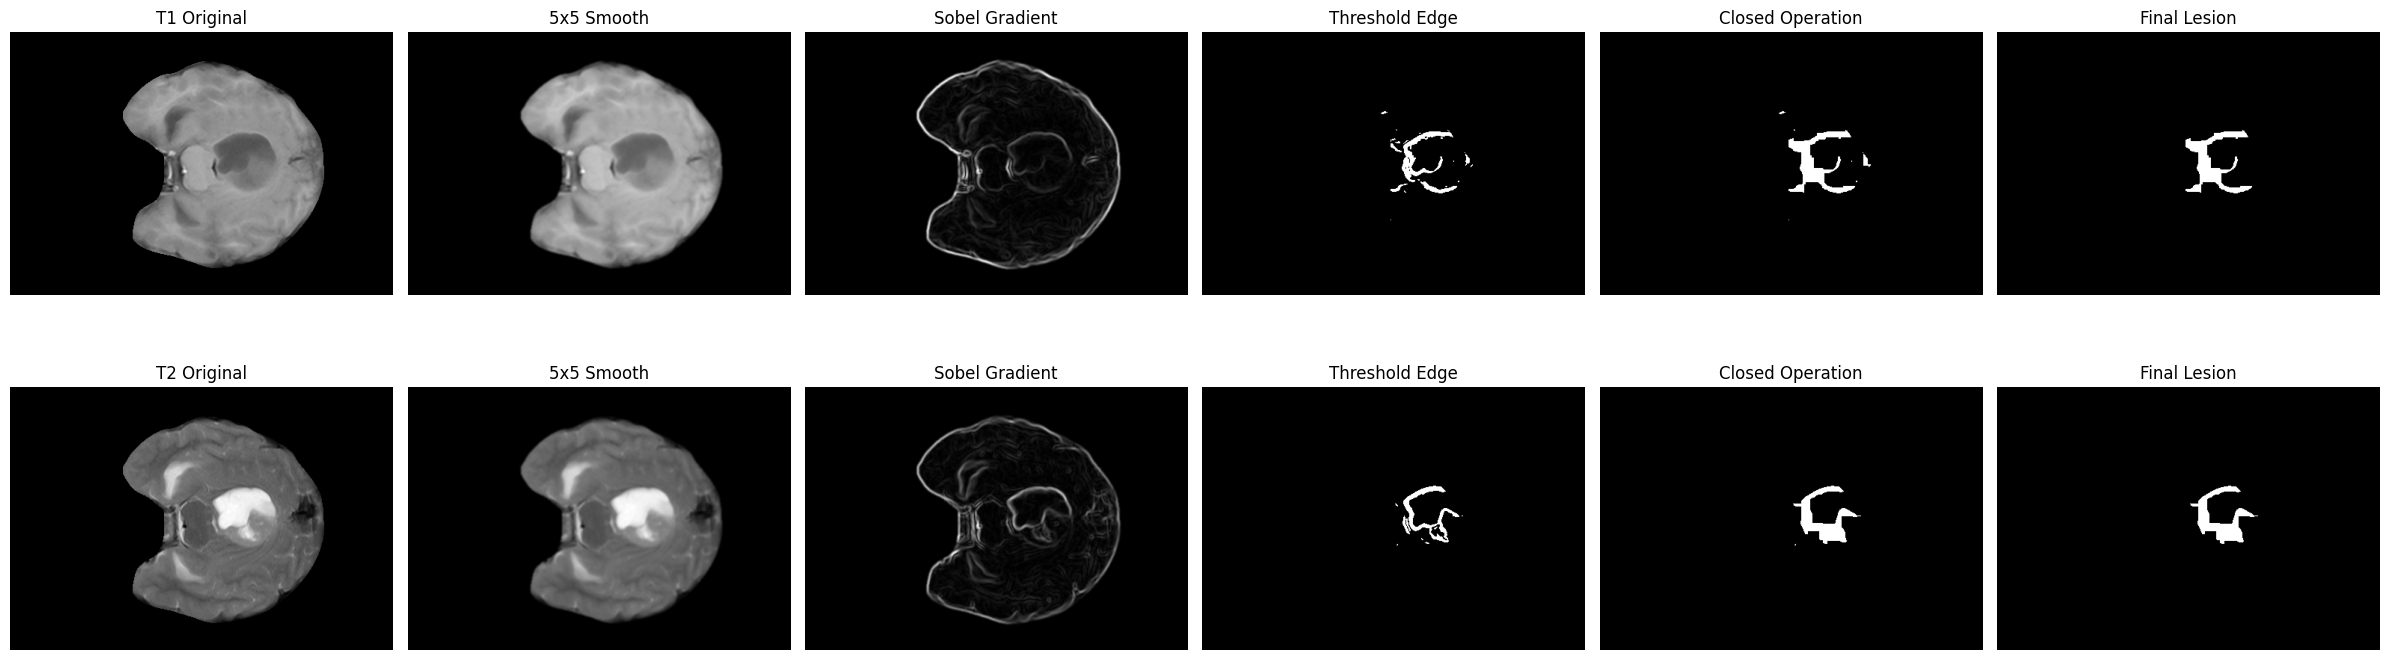

In [63]:
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 数据 ====================
DATA_DIR = Path('.')

T1 = np.load(DATA_DIR / 'T1.npy')
T2 = np.load(DATA_DIR / 'T2.npy')

# ==================== 5x5 Gaussian ====================
def gaussian_kernel(size=5, sigma=1.2):

    ax = np.arange(-(size // 2), size // 2 + 1)

    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))

    return kernel / kernel.sum()


# ==================== Sobel ====================
def sobel_gradient(img):

    gx = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=float)

    gy = np.array([
        [-1, -2, -1],
        [0,  0,  0],
        [1,  2,  1]
    ], dtype=float)

    grad_x = ndi.convolve(img, gx, mode='reflect')
    grad_y = ndi.convolve(img, gy, mode='reflect')

    grad = np.hypot(grad_x, grad_y)

    return grad


# ==================== Brain Mask ====================
def brain_mask(img):

    thresh = np.percentile(img, 20)

    mask = img > thresh

    mask = ndi.binary_fill_holes(mask)

    labeled, num = ndi.label(mask)

    if num == 0:
        return mask

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0

    largest = np.argmax(sizes)

    mask = labeled == largest

    return mask


# ==================== 主 Pipeline ====================
def lesion_segmentation(img,
                        percentile=97,
                        erosion_iter=15,
                        close_size=11,
                        min_size=200):

    # ---------- normalize ----------
    img = img.astype(np.float32)

    img = (img - img.min()) / (img.max() - img.min())

    # ---------- 5x5 smoothing ----------
    kernel = gaussian_kernel(5, sigma=1.2)

    smooth = ndi.convolve(img, kernel, mode='reflect')

    # ---------- Sobel ----------
    grad = sobel_gradient(smooth)

    # normalize gradient
    grad = grad / (grad.max() + 1e-8)

    # ---------- threshold ----------
    T = np.percentile(grad, percentile)

    edge = grad > T

    # ---------- remove brain edge ----------
    brain = brain_mask(smooth)

    # 强腐蚀
    inner = ndi.binary_erosion(
        brain,
        structure=np.ones((7,7)),
        iterations=erosion_iter
    )

    edge = edge & inner

    # ---------- closed operation ----------
    edge_closed = ndi.binary_closing(
        edge,
        structure=np.ones((close_size, close_size))
    )

    # 填洞
    edge_closed = ndi.binary_fill_holes(edge_closed)

    # ---------- connected domain ----------
    labeled, num = ndi.label(edge_closed)

    final_mask = np.zeros_like(edge_closed)

    if num > 0:

        sizes = np.bincount(labeled.ravel())

        sizes[0] = 0

        # 保留较大区域
        keep = np.where(sizes >= min_size)[0]

        mask = np.isin(labeled, keep)

        # 只保留最大连通域
        labeled2, num2 = ndi.label(mask)

        if num2 > 0:

            sizes2 = np.bincount(labeled2.ravel())

            sizes2[0] = 0

            largest = np.argmax(sizes2)

            final_mask = labeled2 == largest

    return smooth, grad, edge, edge_closed, final_mask


# ==================== 参数 ====================
configs = {
    'T1': {
        'percentile': 90,
        'erosion_iter': 16,
        'close_size': 13,
        'min_size': 120
    },

    'T2': {
        'percentile': 95,
        'erosion_iter': 18,
        'close_size': 15,
        'min_size': 180
    }
}

# ==================== Run ====================
results = {}

for name, img in [('T1', T1), ('T2', T2)]:

    cfg = configs[name]

    results[name] = lesion_segmentation(
        img,
        percentile=cfg['percentile'],
        erosion_iter=cfg['erosion_iter'],
        close_size=cfg['close_size'],
        min_size=cfg['min_size']
    )

# ==================== Visualization ====================
fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for row, name in enumerate(['T1', 'T2']):

    smooth, grad, edge, closed, mask = results[name]

    original = T1 if name == 'T1' else T2

    axes[row,0].imshow(original, cmap='gray')
    axes[row,0].set_title(f'{name} Original')

    axes[row,1].imshow(smooth, cmap='gray')
    axes[row,1].set_title('5x5 Smooth')

    axes[row,2].imshow(grad, cmap='gray')
    axes[row,2].set_title('Sobel Gradient')

    axes[row,3].imshow(edge, cmap='gray')
    axes[row,3].set_title('Threshold Edge')

    axes[row,4].imshow(closed, cmap='gray')
    axes[row,4].set_title('Closed Operation')

    axes[row,5].imshow(mask, cmap='gray')
    axes[row,5].set_title('Final Lesion')

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.show()

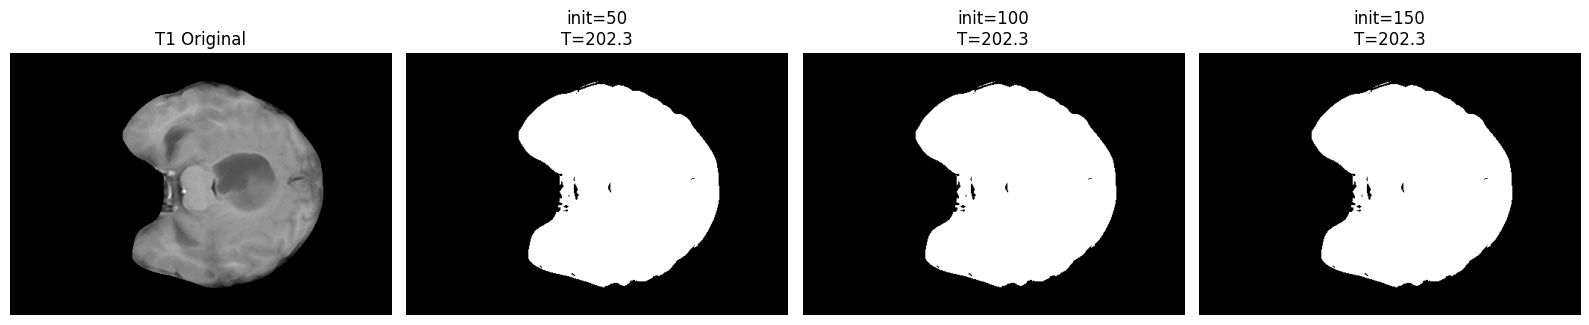

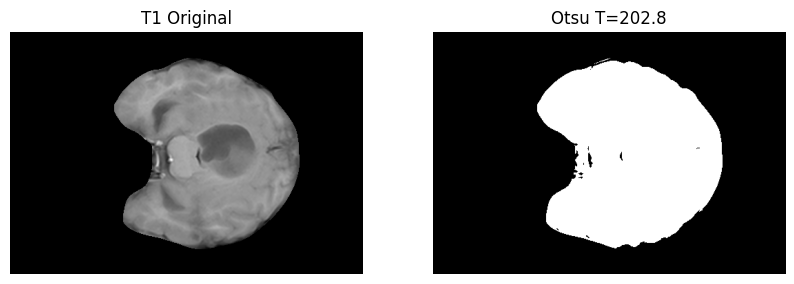

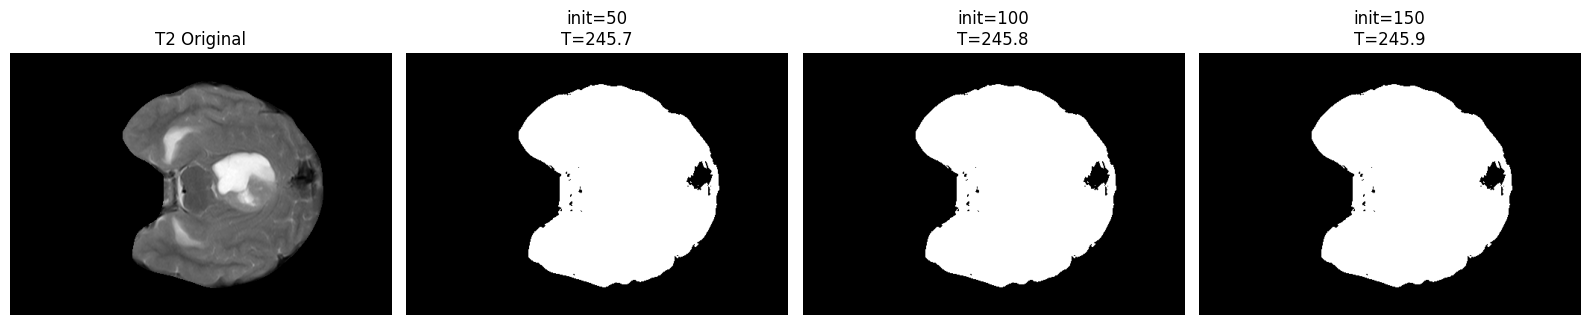

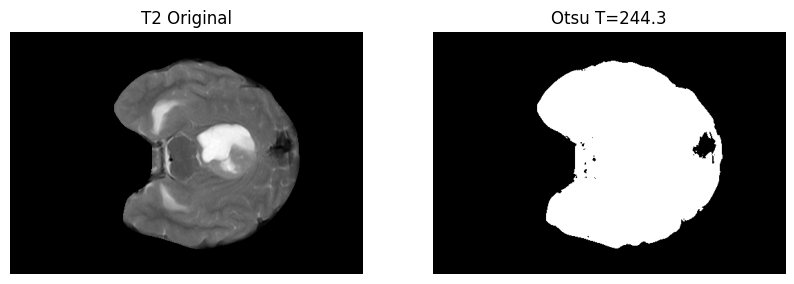

In [64]:
def iterative_threshold(img, initial):
    T = initial
    for _ in range(50):
        bg = img[img <= T]
        fg = img[img > T]
        if len(bg) == 0 or len(fg) == 0:
            break
        new_T = (bg.mean() + fg.mean()) / 2
        if abs(new_T - T) < 0.5:
            break
        T = new_T
    return T, img > T

def otsu_threshold(img):
    hist, bins = np.histogram(img.ravel(), bins=256, range=(img.min(), img.max()))
    bin_centers = (bins[:-1] + bins[1:]) / 2
    weight1 = np.cumsum(hist)
    weight2 = np.cumsum(hist[::-1])[::-1]
    mean1 = np.cumsum(hist * bin_centers) / weight1
    mean2 = (np.cumsum((hist * bin_centers)[::-1]) / weight2[::-1])[::-1]
    variance12 = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:])**2
    idx = np.argmax(variance12)
    return bin_centers[idx]

init_values = [50, 100, 150]
project2_results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    project2_results[name] = {}
    for init in init_values:
        T_iter, mask_iter = iterative_threshold(img, init)
        project2_results[name][f'iter_{init}'] = (T_iter, mask_iter)
    T_otsu = otsu_threshold(img)
    project2_results[name]['otsu'] = (T_otsu, img > T_otsu)

for name in ['T1', 'T2']:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(eval(name), cmap='gray')
    axes[0].set_title(f'{name} Original')
    axes[0].axis('off')
    for col, init in enumerate(init_values, start=1):
        T_iter, mask_iter = project2_results[name][f'iter_{init}']
        axes[col].imshow(mask_iter, cmap='gray')
        axes[col].set_title(f'init={init}\nT={T_iter:.1f}')
        axes[col].axis('off')
    fig.tight_layout()
    plt.show()
    T_otsu, mask_otsu = project2_results[name]['otsu']
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(eval(name), cmap='gray')
    ax[0].set_title(f'{name} Original')
    ax[0].axis('off')
    ax[1].imshow(mask_otsu, cmap='gray')
    ax[1].set_title(f'Otsu T={T_otsu:.1f}')
    ax[1].axis('off')
    plt.show()


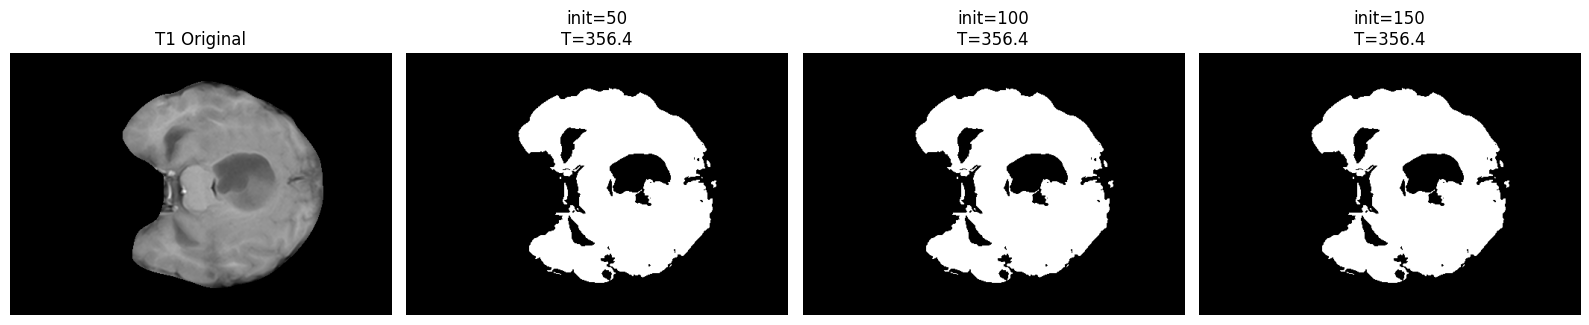

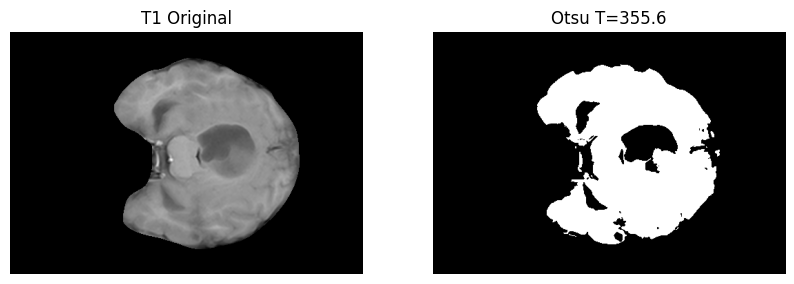

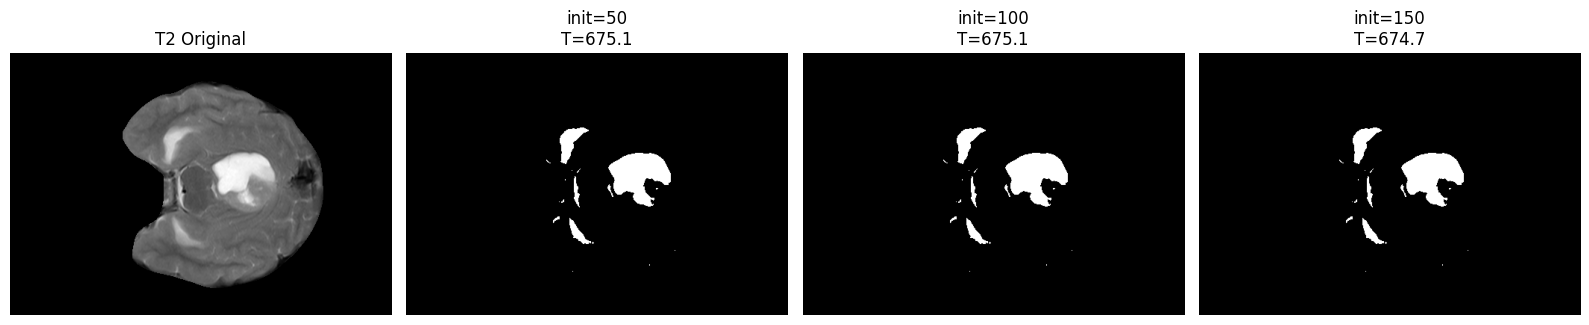

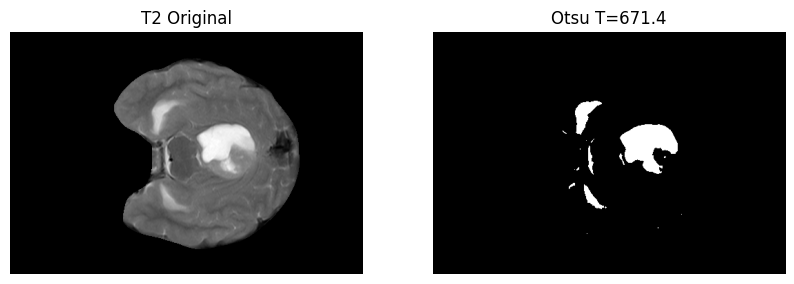

In [65]:
# ==================== Project 2: 全局阈值分割（改进版） ====================

def iterative_threshold(img, initial, mask=None):
    """迭代全局阈值，可选 mask 限定计算区域"""
    if mask is None:
        mask = np.ones_like(img, dtype=bool)
    pixels = img[mask]
    T = initial
    for _ in range(50):
        bg = pixels[pixels <= T]
        fg = pixels[pixels > T]
        if len(bg) == 0 or len(fg) == 0:
            break
        new_T = (bg.mean() + fg.mean()) / 2
        if abs(new_T - T) < 0.5:
            break
        T = new_T
    return T, (img > T) & mask

def otsu_threshold(img, mask=None):
    """Otsu 最优阈值，可选 mask 限定计算区域"""
    if mask is None:
        mask = np.ones_like(img, dtype=bool)
    pixels = img[mask]
    hist, bins = np.histogram(pixels, bins=256, range=(pixels.min(), pixels.max()))
    bin_centers = (bins[:-1] + bins[1:]) / 2
    weight1 = np.cumsum(hist)
    weight2 = np.cumsum(hist[::-1])[::-1]
    mean1 = np.cumsum(hist * bin_centers) / weight1
    mean2 = (np.cumsum((hist * bin_centers)[::-1]) / weight2[::-1])[::-1]
    variance12 = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:])**2
    idx = np.argmax(variance12)
    return bin_centers[idx]

# ==================== 运行 ====================
init_values = [50, 100, 150]
project2_results = {}
for name, img in [('T1', T1), ('T2', T2)]:
    bm = brain_mask(img)  # 复用 Project 1 的脑掩码
    project2_results[name] = {}
    for init in init_values:
        T_iter, mask_iter = iterative_threshold(img, init, mask=bm)
        project2_results[name][f'iter_{init}'] = (T_iter, mask_iter)
    T_otsu = otsu_threshold(img, mask=bm)
    project2_results[name]['otsu'] = (T_otsu, (img > T_otsu) & bm)

# ==================== 可视化 ====================
for name in ['T1', 'T2']:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(eval(name), cmap='gray')
    axes[0].set_title(f'{name} Original')
    axes[0].axis('off')
    for col, init in enumerate(init_values, start=1):
        T_iter, mask_iter = project2_results[name][f'iter_{init}']
        axes[col].imshow(mask_iter, cmap='gray')
        axes[col].set_title(f'init={init}\nT={T_iter:.1f}')
        axes[col].axis('off')
    fig.tight_layout()
    plt.show()

    T_otsu, mask_otsu = project2_results[name]['otsu']
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(eval(name), cmap='gray')
    ax[0].set_title(f'{name} Original')
    ax[0].axis('off')
    ax[1].imshow(mask_otsu, cmap='gray')
    ax[1].set_title(f'Otsu T={T_otsu:.1f}')
    ax[1].axis('off')
    plt.show()


Seed coordinate: (np.int64(166), np.int64(292)) value= 1127.0
Region growing area(mm^2): 1374.0
Standard K-means area(mm^2): 127599.0
Spatial K-means area(mm^2): 127599.0
Watershed seed mask area(mm^2): 180087.0


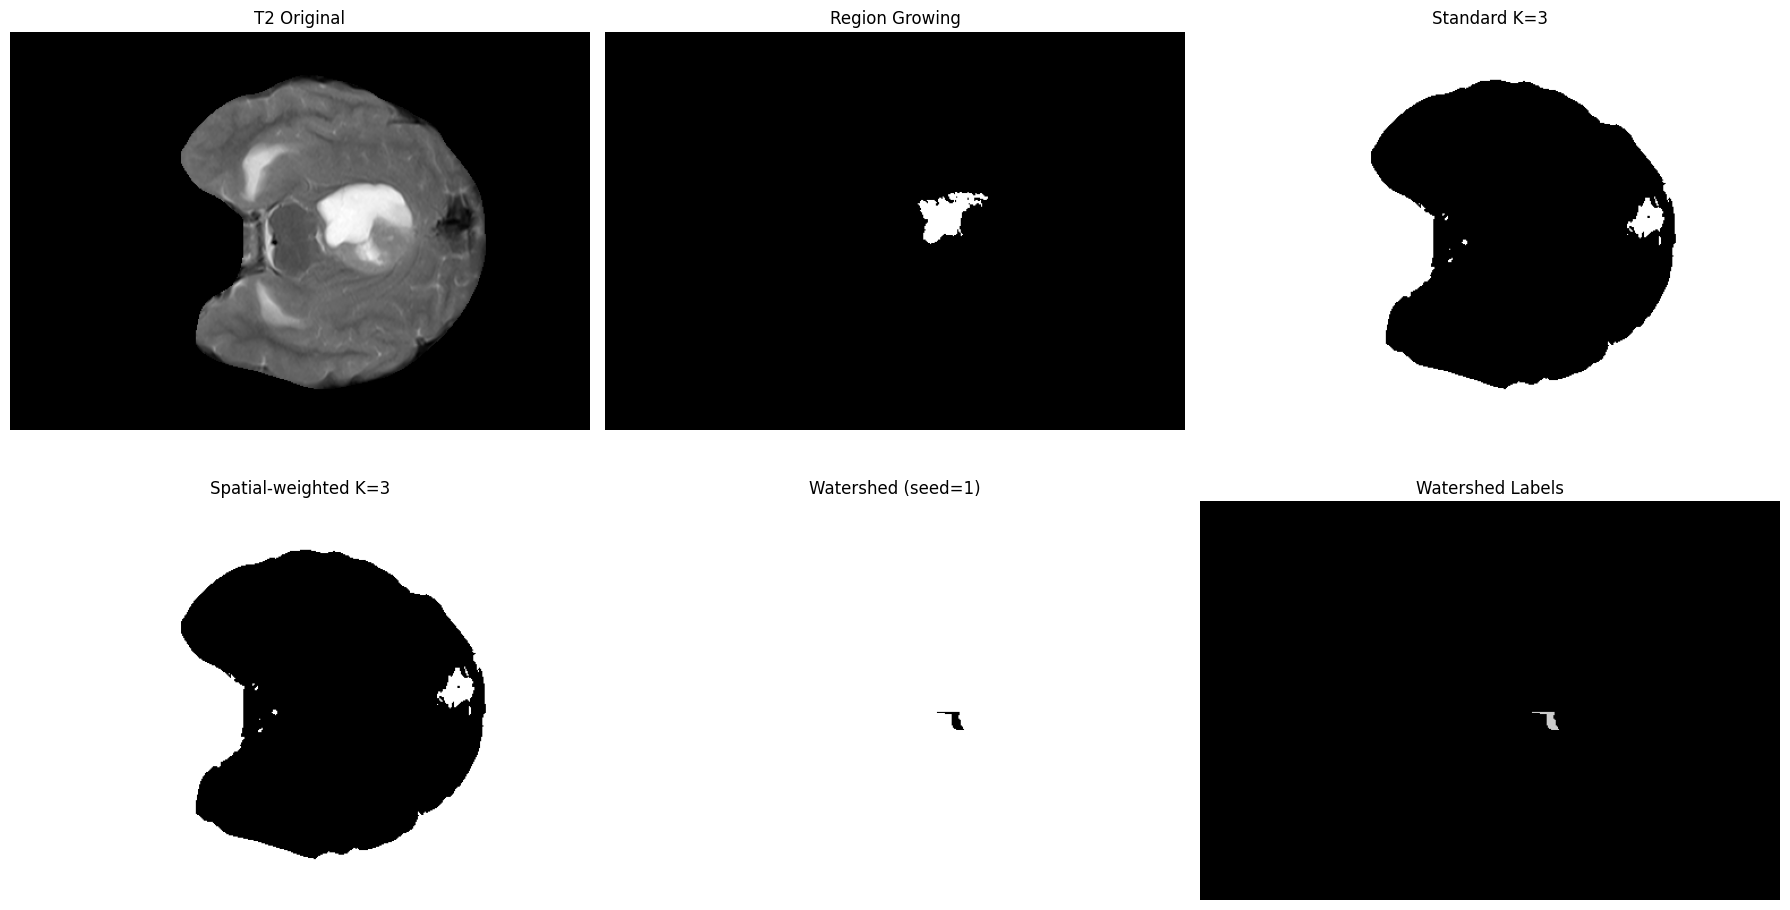

In [9]:
def region_growing(img, seed, thresh):
    h, w = img.shape
    mask = np.zeros_like(img, dtype=bool)
    stack = [seed]
    seed_val = img[seed]
    while stack:
        y, x = stack.pop()
        if mask[y, x]:
            continue
        if abs(float(img[y, x]) - float(seed_val)) <= thresh:
            mask[y, x] = True
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not mask[ny, nx]:
                        stack.append((ny, nx))
    return mask

def kmeans(img, K=3, spatial_weight=0.0, iterations=20):
    h, w = img.shape
    coords_y, coords_x = np.indices(img.shape)
    features = np.stack([img.ravel(), coords_y.ravel() * spatial_weight, coords_x.ravel() * spatial_weight], axis=1)
    rng = np.random.default_rng(123)
    centers = features[rng.choice(features.shape[0], size=K, replace=False)]
    labels = np.zeros(features.shape[0], dtype=int)
    for _ in range(iterations):
        d = np.linalg.norm(features[:, None] - centers[None, :], axis=2)
        labels = np.argmin(d, axis=1)
        for k in range(K):
            members = features[labels == k]
            if len(members):
                centers[k] = members.mean(axis=0)
    return labels.reshape(h, w), centers

seed = np.unravel_index(np.argmax(T2), T2.shape)
region_mask = region_growing(T2, seed, thresh=80)
k3_mask, _ = kmeans(T2, K=3, spatial_weight=0.0)
k3_spatial_mask, _ = kmeans(T2, K=3, spatial_weight=0.03)
img_int = (T2 - T2.min()).astype(np.uint16)
markers = np.zeros(T2.shape, dtype=np.int32)
markers[seed] = 1
markers[min(seed[0] + 20, T2.shape[0] - 1), min(seed[1] + 20, T2.shape[1] - 1)] = 2
watershed_label = ndi.watershed_ift(img_int, markers)
watershed_mask = watershed_label == 1

def lesion_area(mask):
    return mask.sum() * 1.0

print('Seed coordinate:', seed, 'value=', T2[seed])
print('Region growing area(mm^2):', lesion_area(region_mask))
print('Standard K-means area(mm^2):', lesion_area(k3_mask == np.argmax(np.bincount(k3_mask.ravel()))))
print('Spatial K-means area(mm^2):', lesion_area(k3_spatial_mask == np.argmax(np.bincount(k3_spatial_mask.ravel()))))
print('Watershed seed mask area(mm^2):', lesion_area(watershed_mask))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(T2, cmap='gray')
axes[0, 0].set_title('T2 Original')
axes[0, 1].imshow(region_mask, cmap='gray')
axes[0, 1].set_title('Region Growing')
axes[0, 2].imshow(k3_mask == np.argmax(np.bincount(k3_mask.ravel())), cmap='gray')
axes[0, 2].set_title('Standard K=3')
axes[1, 0].imshow(k3_spatial_mask == np.argmax(np.bincount(k3_spatial_mask.ravel())), cmap='gray')
axes[1, 0].set_title('Spatial-weighted K=3')
axes[1, 1].imshow(watershed_mask, cmap='gray')
axes[1, 1].set_title('Watershed (seed=1)')
axes[1, 2].imshow(watershed_label, cmap='nipy_spectral')
axes[1, 2].set_title('Watershed Labels')
for ax in axes.ravel():
    ax.axis('off')
fig.tight_layout()
plt.show()


K=2, spatial_weight=0.000 → area=52213 mm²
K=2, spatial_weight=0.010 → area=52213 mm²
K=2, spatial_weight=0.030 → area=52213 mm²
K=2, spatial_weight=0.050 → area=52213 mm²
K=2, spatial_weight=0.100 → area=52213 mm²
K=3, spatial_weight=0.000 → area=4999 mm²
K=3, spatial_weight=0.010 → area=4999 mm²
K=3, spatial_weight=0.030 → area=4999 mm²
K=3, spatial_weight=0.050 → area=52176 mm²
K=3, spatial_weight=0.100 → area=52181 mm²
K=4, spatial_weight=0.000 → area=4706 mm²
K=4, spatial_weight=0.010 → area=4746 mm²
K=4, spatial_weight=0.030 → area=4999 mm²
K=4, spatial_weight=0.050 → area=52176 mm²
K=4, spatial_weight=0.100 → area=52178 mm²
K=5, spatial_weight=0.000 → area=4509 mm²
K=5, spatial_weight=0.010 → area=4732 mm²
K=5, spatial_weight=0.030 → area=4999 mm²
K=5, spatial_weight=0.050 → area=4999 mm²
K=5, spatial_weight=0.100 → area=4999 mm²

===== 病灶面积汇总 =====
Region Growing:          1374 mm²
Watershed:               180087 mm²
K-means K=3 w=0.00:       4999 mm²
K-means K=3 w=0.01:       

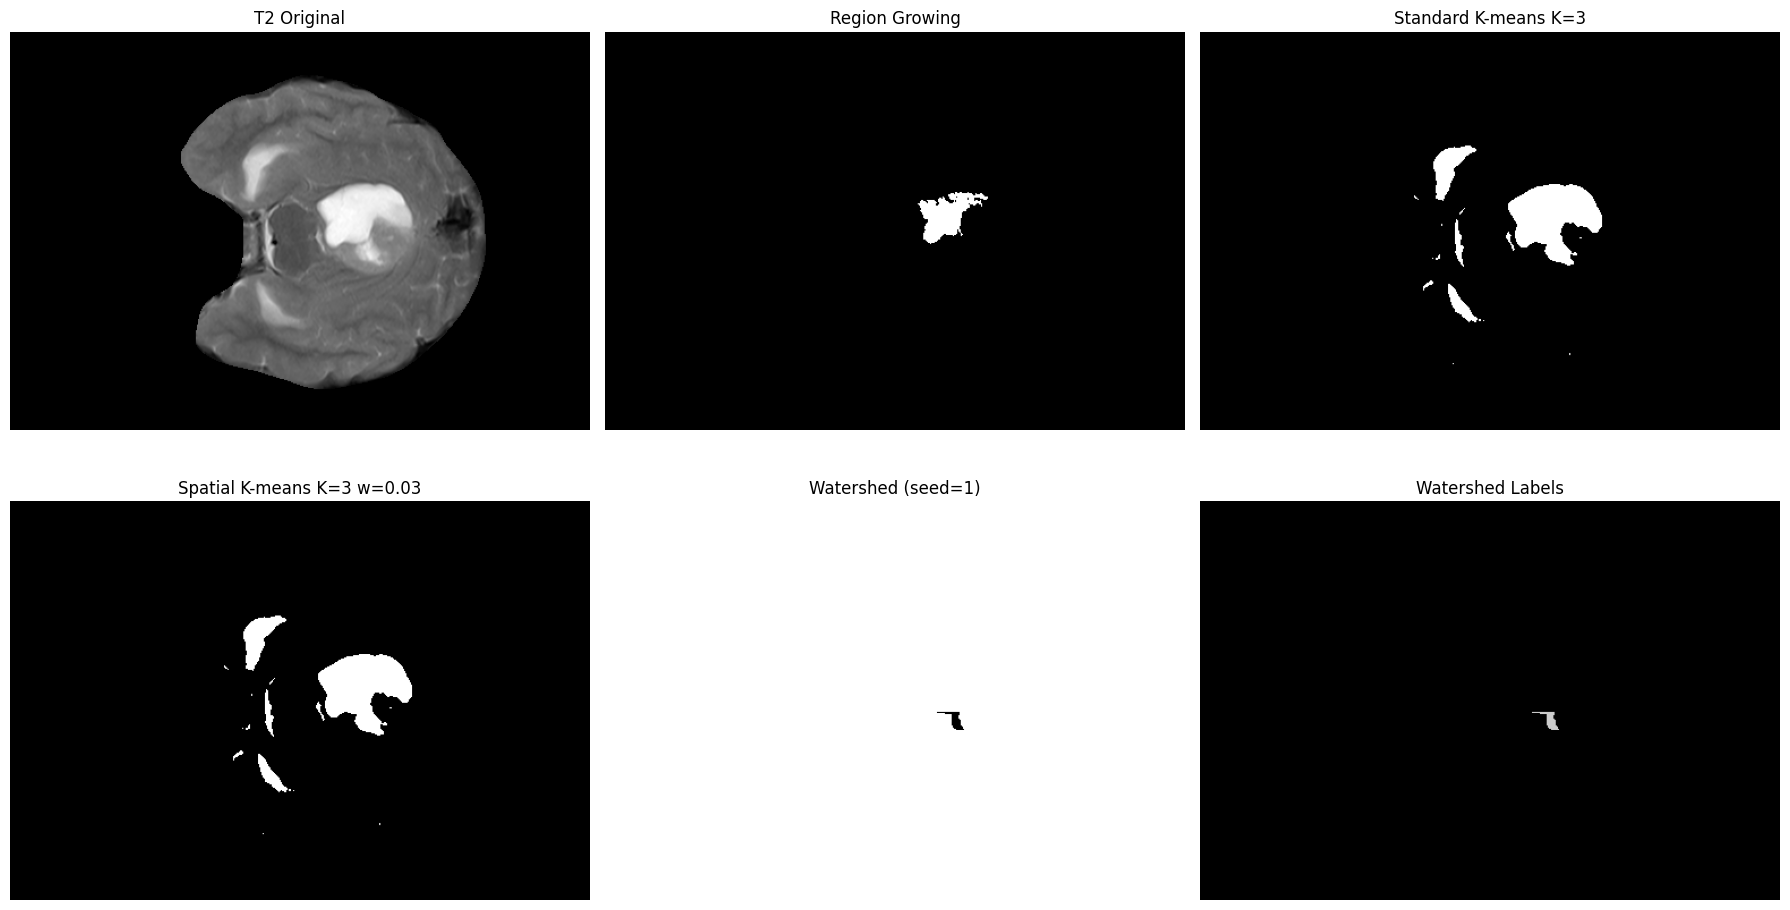

C:\Users\26971\AppData\Local\Temp\ipykernel_19744\2823806679.py:118: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\26971\AppData\Local\Temp\ipykernel_19744\2823806679.py:118: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\26971\AppData\Local\Temp\ipykernel_19744\2823806679.py:118: UserWarning: Glyph 21709 (\N{CJK UNIFIED IDEOGRAPH-54CD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
d:\coding\DIP_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\coding\DIP_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\coding\DIP_project\.venv\Li

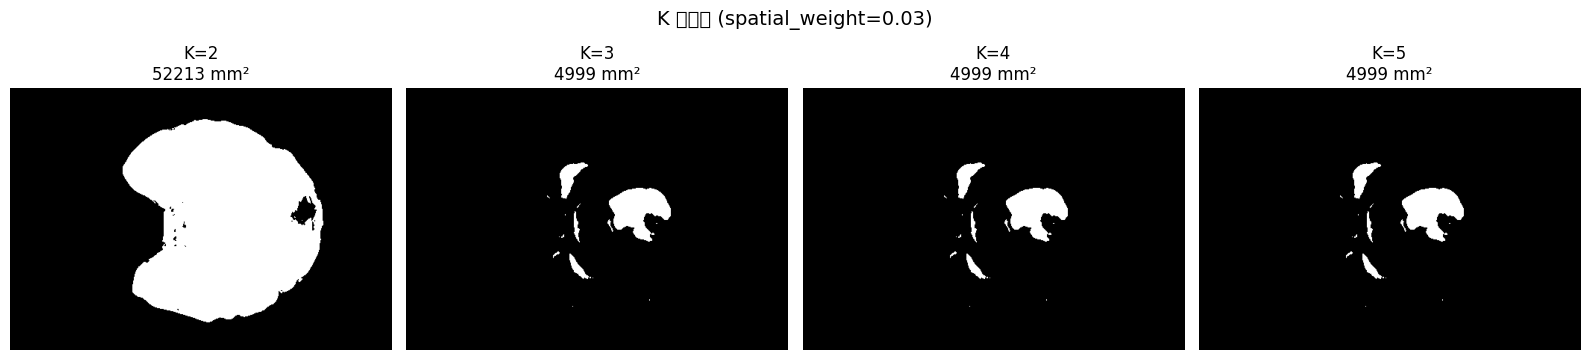

C:\Users\26971\AppData\Local\Temp\ipykernel_19744\2823806679.py:128: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\26971\AppData\Local\Temp\ipykernel_19744\2823806679.py:128: UserWarning: Glyph 21709 (\N{CJK UNIFIED IDEOGRAPH-54CD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


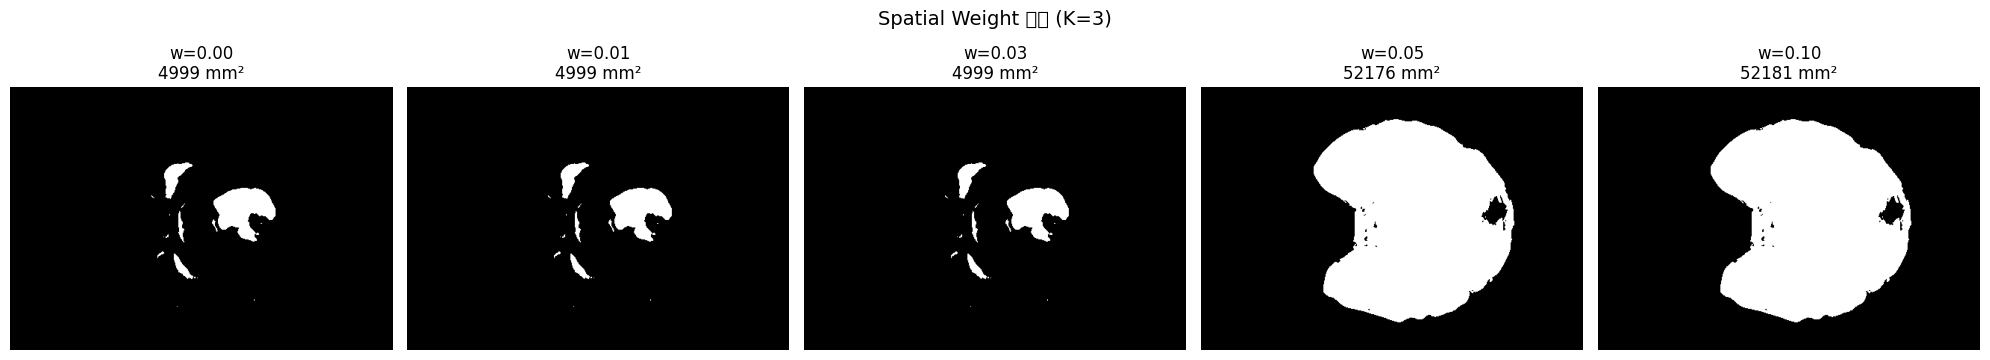

In [66]:
# ==================== Project 3: T2 分割与体积计算（完整版） ====================

def region_growing(img, seed, thresh):
    h, w = img.shape
    mask = np.zeros_like(img, dtype=bool)
    stack = [seed]
    seed_val = img[seed]
    while stack:
        y, x = stack.pop()
        if mask[y, x]:
            continue
        if abs(float(img[y, x]) - float(seed_val)) <= thresh:
            mask[y, x] = True
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not mask[ny, nx]:
                        stack.append((ny, nx))
    return mask

def kmeans(img, K=3, spatial_weight=0.0, iterations=20):
    h, w = img.shape
    coords_y, coords_x = np.indices(img.shape)
    features = np.stack([img.ravel(),
                         coords_y.ravel() * spatial_weight,
                         coords_x.ravel() * spatial_weight], axis=1)
    rng = np.random.default_rng(123)
    centers = features[rng.choice(features.shape[0], size=K, replace=False)]
    labels = np.zeros(features.shape[0], dtype=int)
    for _ in range(iterations):
        d = np.linalg.norm(features[:, None] - centers[None, :], axis=2)
        labels = np.argmin(d, axis=1)
        for k in range(K):
            members = features[labels == k]
            if len(members):
                centers[k] = members.mean(axis=0)
    return labels.reshape(h, w), centers

def lesion_area(mask):
    return mask.sum() * 1.0  # 1mm x 1mm resolution

# ==================== 1. Region Growing ====================
seed = np.unravel_index(np.argmax(T2), T2.shape)
region_mask = region_growing(T2, seed, thresh=80)

# ==================== 2. 改进 K-means: 测试不同 K 和 spatial_weight 组合 ====================
K_values = [2, 3, 4, 5]
weight_values = [0.0, 0.01, 0.03, 0.05, 0.1]

kmeans_results = {}
for K in K_values:
    for w in weight_values:
        labels, centers = kmeans(T2, K=K, spatial_weight=w)
        # 取聚类中心强度最高的那一类作为病灶
        intensity_order = np.argsort(centers[:, 0])
        lesion_cluster = intensity_order[-1]
        mask = labels == lesion_cluster
        kmeans_results[(K, w)] = (mask, labels, centers)
        area = lesion_area(mask)
        print(f'K={K}, spatial_weight={w:.3f} → area={area:.0f} mm²')

# ==================== 3. Watershed ====================
img_int = (T2 - T2.min()).astype(np.uint16)
markers = np.zeros(T2.shape, dtype=np.int32)
markers[seed] = 1
markers[min(seed[0] + 20, T2.shape[0] - 1), min(seed[1] + 20, T2.shape[1] - 1)] = 2
watershed_label = ndi.watershed_ift(img_int, markers)
watershed_mask = watershed_label == 1

# ==================== 4. 对比标准 K-means 与空间加权 K-means ====================
# 选定 K=3，对比 5 个 spatial_weight
compare_weights = [0.0, 0.01, 0.03, 0.05, 0.1]
compare_masks = {}
for w in compare_weights:
    labels, centers = kmeans(T2, K=3, spatial_weight=w)
    lesion_cluster = np.argmax(centers[:, 0])
    compare_masks[w] = labels == lesion_cluster

# ==================== 5. 所有结果汇总 ====================
print('\n===== 病灶面积汇总 =====')
print(f'Region Growing:          {lesion_area(region_mask):.0f} mm²')
print(f'Watershed:               {lesion_area(watershed_mask):.0f} mm²')
for w in compare_weights:
    print(f'K-means K=3 w={w:.2f}:       {lesion_area(compare_masks[w]):.0f} mm²')

# ==================== 可视化 ====================
# -- 图1: 四类方法总览 (2x3) --
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(T2, cmap='gray')
axes[0, 0].set_title('T2 Original')
axes[0, 1].imshow(region_mask, cmap='gray')
axes[0, 1].set_title('Region Growing')
# 标准 K-means K=3
km_std_mask, _, _ = kmeans_results[(3, 0.0)]
axes[0, 2].imshow(km_std_mask, cmap='gray')
axes[0, 2].set_title('Standard K-means K=3')
# 空间加权 K-means K=3 w=0.03
km_sp_mask, _, _ = kmeans_results[(3, 0.03)]
axes[1, 0].imshow(km_sp_mask, cmap='gray')
axes[1, 0].set_title('Spatial K-means K=3 w=0.03')
axes[1, 1].imshow(watershed_mask, cmap='gray')
axes[1, 1].set_title('Watershed (seed=1)')
axes[1, 2].imshow(watershed_label, cmap='nipy_spectral')
axes[1, 2].set_title('Watershed Labels')
for ax in axes.ravel():
    ax.axis('off')
fig.tight_layout()
plt.show()

# -- 图2: K 值对比 (固定 w=0.03) --
fig, axes = plt.subplots(1, len(K_values), figsize=(4*len(K_values), 4))
for i, K in enumerate(K_values):
    mask, _, _ = kmeans_results[(K, 0.03)]
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f'K={K}\n{lesion_area(mask):.0f} mm²')
    axes[i].axis('off')
fig.suptitle('K 值影响 (spatial_weight=0.03)', fontsize=14)
fig.tight_layout()
plt.show()

# -- 图3: spatial_weight 对比 (固定 K=3) --
fig, axes = plt.subplots(1, len(compare_weights), figsize=(4*len(compare_weights), 4))
for i, w in enumerate(compare_weights):
    axes[i].imshow(compare_masks[w], cmap='gray')
    axes[i].set_title(f'w={w:.2f}\n{lesion_area(compare_masks[w]):.0f} mm²')
    axes[i].axis('off')
fig.suptitle('Spatial Weight 影响 (K=3)', fontsize=14)
fig.tight_layout()
plt.show()


K=2, spatial_weight=0.000 -> area=52213 mm^2
K=2, spatial_weight=0.010 -> area=52213 mm^2
K=2, spatial_weight=0.030 -> area=52213 mm^2
K=2, spatial_weight=0.050 -> area=52213 mm^2
K=2, spatial_weight=0.100 -> area=52213 mm^2
K=3, spatial_weight=0.000 -> area=4999 mm^2
K=3, spatial_weight=0.010 -> area=4999 mm^2
K=3, spatial_weight=0.030 -> area=4999 mm^2
K=3, spatial_weight=0.050 -> area=52176 mm^2
K=3, spatial_weight=0.100 -> area=52181 mm^2
K=4, spatial_weight=0.000 -> area=4706 mm^2
K=4, spatial_weight=0.010 -> area=4746 mm^2
K=4, spatial_weight=0.030 -> area=4999 mm^2
K=4, spatial_weight=0.050 -> area=52176 mm^2
K=4, spatial_weight=0.100 -> area=52178 mm^2
K=5, spatial_weight=0.000 -> area=4509 mm^2
K=5, spatial_weight=0.010 -> area=4732 mm^2
K=5, spatial_weight=0.030 -> area=4999 mm^2
K=5, spatial_weight=0.050 -> area=4999 mm^2
K=5, spatial_weight=0.100 -> area=4999 mm^2

===== Lesion Area Summary =====
Region Growing:          1374 mm^2
Watershed:               180087 mm^2
K-mean

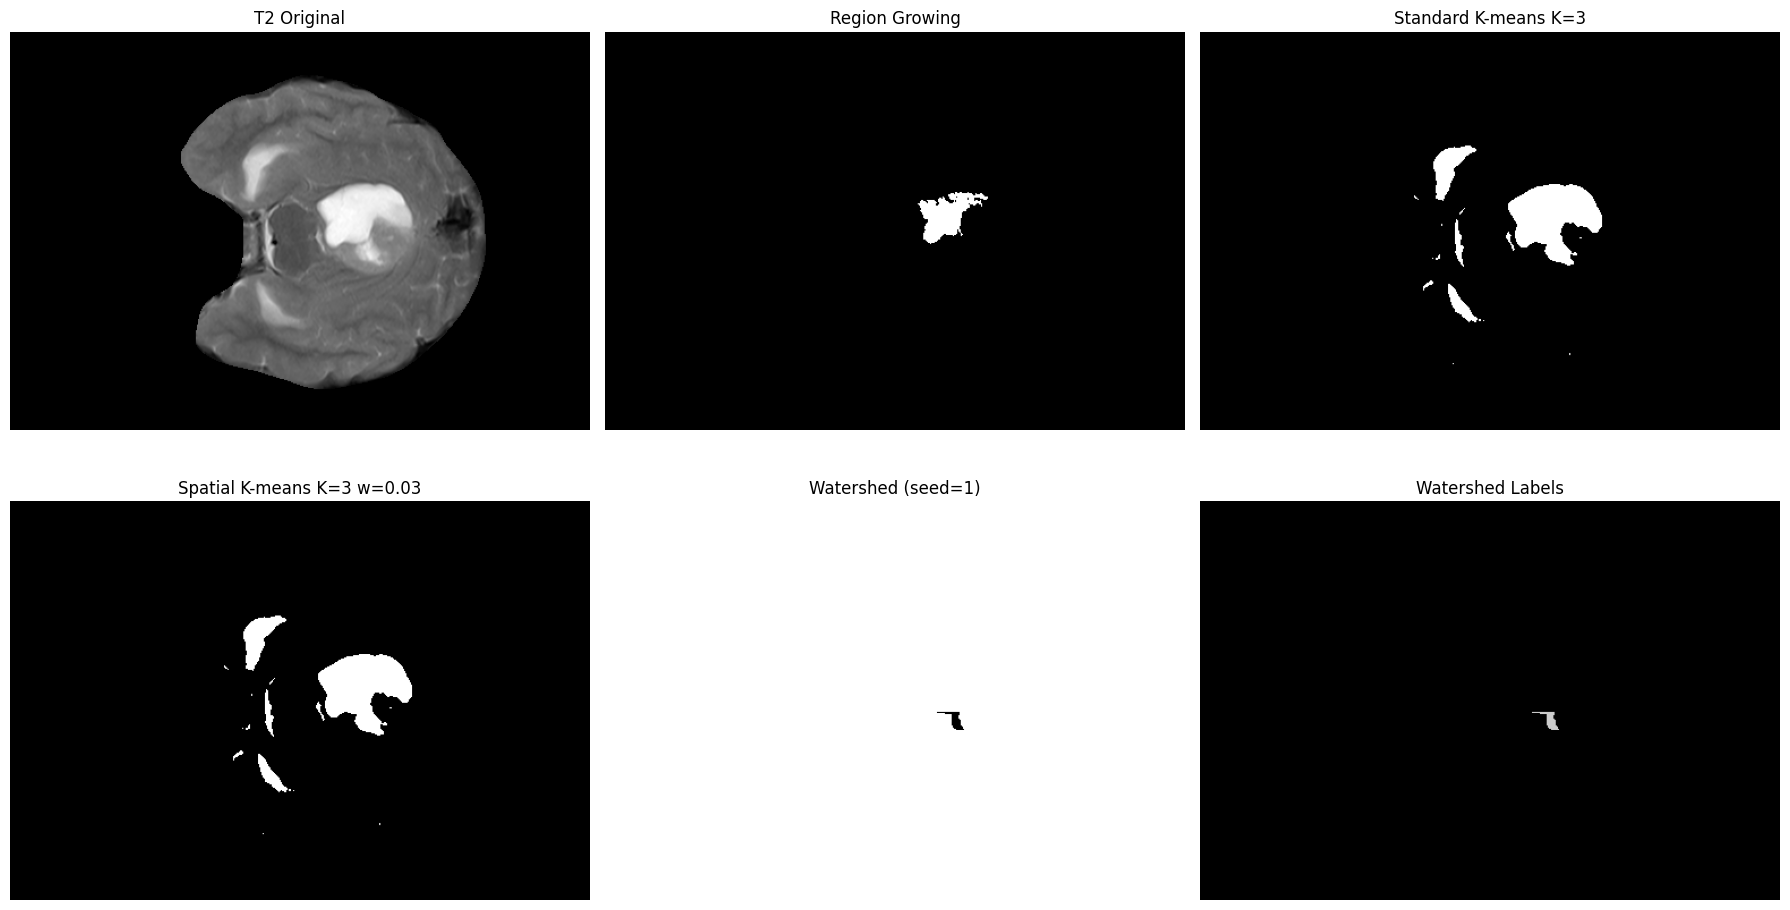

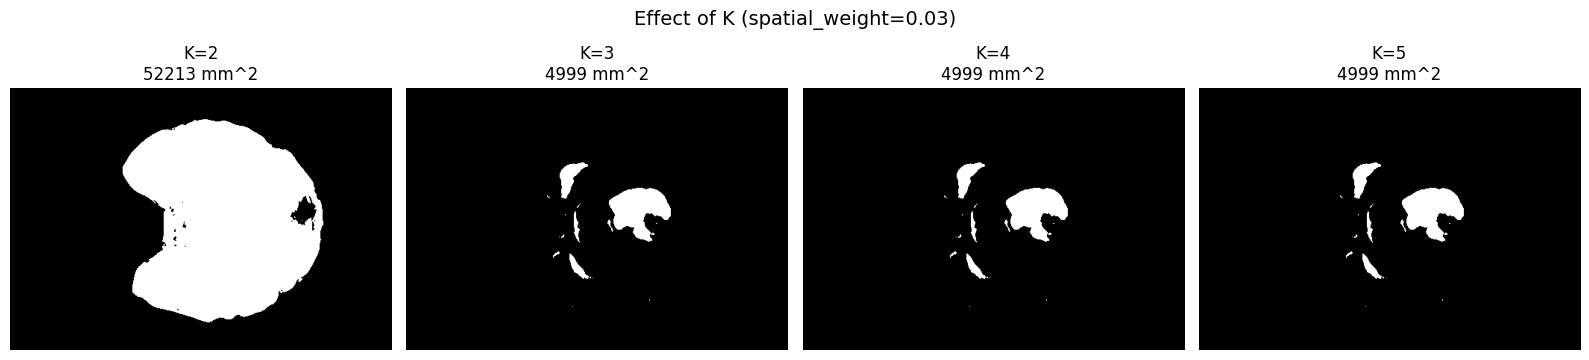

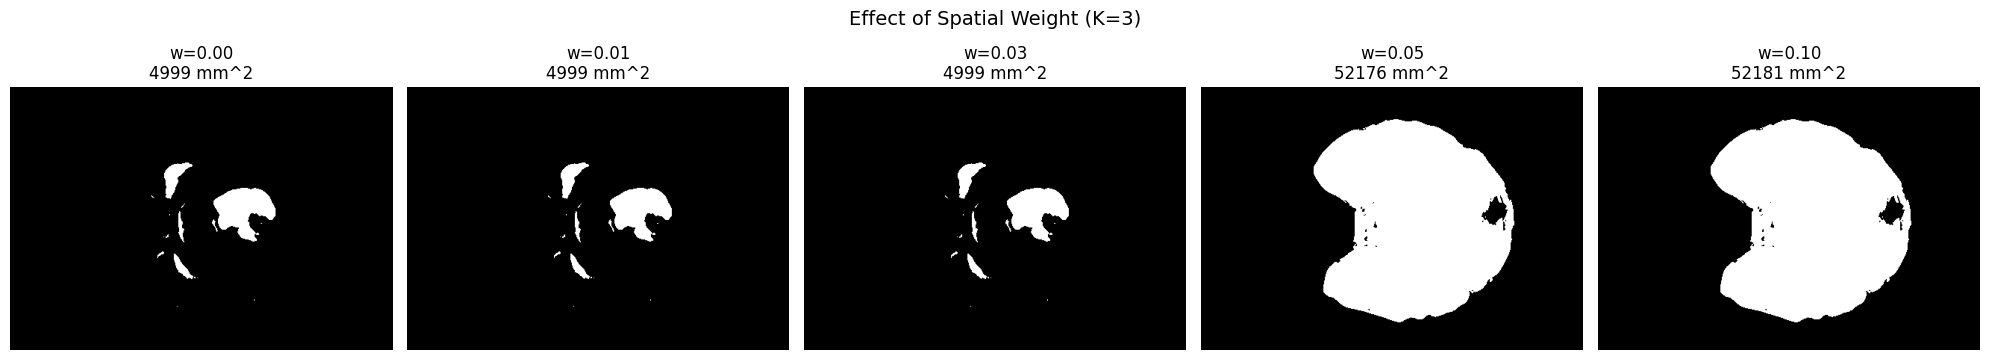

In [67]:
# ==================== Project 3: T2 分割与体积计算（完整版） ====================

def region_growing(img, seed, thresh):
    h, w = img.shape
    mask = np.zeros_like(img, dtype=bool)
    stack = [seed]
    seed_val = img[seed]
    while stack:
        y, x = stack.pop()
        if mask[y, x]:
            continue
        if abs(float(img[y, x]) - float(seed_val)) <= thresh:
            mask[y, x] = True
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not mask[ny, nx]:
                        stack.append((ny, nx))
    return mask

def kmeans(img, K=3, spatial_weight=0.0, iterations=20):
    h, w = img.shape
    coords_y, coords_x = np.indices(img.shape)
    features = np.stack([img.ravel(),
                         coords_y.ravel() * spatial_weight,
                         coords_x.ravel() * spatial_weight], axis=1)
    rng = np.random.default_rng(123)
    centers = features[rng.choice(features.shape[0], size=K, replace=False)]
    labels = np.zeros(features.shape[0], dtype=int)
    for _ in range(iterations):
        d = np.linalg.norm(features[:, None] - centers[None, :], axis=2)
        labels = np.argmin(d, axis=1)
        for k in range(K):
            members = features[labels == k]
            if len(members):
                centers[k] = members.mean(axis=0)
    return labels.reshape(h, w), centers

def lesion_area(mask):
    return mask.sum() * 1.0  # 1mm x 1mm resolution

# ==================== 1. Region Growing ====================
seed = np.unravel_index(np.argmax(T2), T2.shape)
region_mask = region_growing(T2, seed, thresh=80)

# ==================== 2. Improved K-means: test K and spatial_weight ====================
K_values = [2, 3, 4, 5]
weight_values = [0.0, 0.01, 0.03, 0.05, 0.1]

kmeans_results = {}
for K in K_values:
    for w in weight_values:
        labels, centers = kmeans(T2, K=K, spatial_weight=w)
        intensity_order = np.argsort(centers[:, 0])
        lesion_cluster = intensity_order[-1]
        mask = labels == lesion_cluster
        kmeans_results[(K, w)] = (mask, labels, centers)
        area = lesion_area(mask)
        print(f'K={K}, spatial_weight={w:.3f} -> area={area:.0f} mm^2')

# ==================== 3. Watershed ====================
img_int = (T2 - T2.min()).astype(np.uint16)
markers = np.zeros(T2.shape, dtype=np.int32)
markers[seed] = 1
markers[min(seed[0] + 20, T2.shape[0] - 1), min(seed[1] + 20, T2.shape[1] - 1)] = 2
watershed_label = ndi.watershed_ift(img_int, markers)
watershed_mask = watershed_label == 1

# ==================== 4. Standard vs Spatial-weighted K-means ====================
compare_weights = [0.0, 0.01, 0.03, 0.05, 0.1]
compare_masks = {}
for w in compare_weights:
    labels, centers = kmeans(T2, K=3, spatial_weight=w)
    lesion_cluster = np.argmax(centers[:, 0])
    compare_masks[w] = labels == lesion_cluster

# ==================== 5. Summary ====================
print('\n===== Lesion Area Summary =====')
print(f'Region Growing:          {lesion_area(region_mask):.0f} mm^2')
print(f'Watershed:               {lesion_area(watershed_mask):.0f} mm^2')
for w in compare_weights:
    print(f'K-means K=3 w={w:.2f}:       {lesion_area(compare_masks[w]):.0f} mm^2')

# ==================== Visualization ====================
# -- Figure 1: Four methods overview (2x3) --
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(T2, cmap='gray')
axes[0, 0].set_title('T2 Original')
axes[0, 1].imshow(region_mask, cmap='gray')
axes[0, 1].set_title('Region Growing')
km_std_mask, _, _ = kmeans_results[(3, 0.0)]
axes[0, 2].imshow(km_std_mask, cmap='gray')
axes[0, 2].set_title('Standard K-means K=3')
km_sp_mask, _, _ = kmeans_results[(3, 0.03)]
axes[1, 0].imshow(km_sp_mask, cmap='gray')
axes[1, 0].set_title('Spatial K-means K=3 w=0.03')
axes[1, 1].imshow(watershed_mask, cmap='gray')
axes[1, 1].set_title('Watershed (seed=1)')
axes[1, 2].imshow(watershed_label, cmap='nipy_spectral')
axes[1, 2].set_title('Watershed Labels')
for ax in axes.ravel():
    ax.axis('off')
fig.tight_layout()
plt.show()

# -- Figure 2: Effect of K (spatial_weight=0.03) --
fig, axes = plt.subplots(1, len(K_values), figsize=(4*len(K_values), 4))
for i, K in enumerate(K_values):
    mask, _, _ = kmeans_results[(K, 0.03)]
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f'K={K}\n{lesion_area(mask):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of K (spatial_weight=0.03)', fontsize=14)
fig.tight_layout()
plt.show()

# -- Figure 3: Effect of spatial_weight (K=3) --
fig, axes = plt.subplots(1, len(compare_weights), figsize=(4*len(compare_weights), 4))
for i, w in enumerate(compare_weights):
    axes[i].imshow(compare_masks[w], cmap='gray')
    axes[i].set_title(f'w={w:.2f}\n{lesion_area(compare_masks[w]):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of Spatial Weight (K=3)', fontsize=14)
fig.tight_layout()
plt.show()


K=2, spatial_weight=0.000 -> area=52213 mm^2
K=2, spatial_weight=0.010 -> area=52213 mm^2
K=2, spatial_weight=0.030 -> area=52213 mm^2
K=2, spatial_weight=0.050 -> area=52213 mm^2
K=2, spatial_weight=0.100 -> area=52213 mm^2
K=3, spatial_weight=0.000 -> area=4999 mm^2
K=3, spatial_weight=0.010 -> area=4999 mm^2
K=3, spatial_weight=0.030 -> area=4999 mm^2
K=3, spatial_weight=0.050 -> area=52176 mm^2
K=3, spatial_weight=0.100 -> area=52181 mm^2
K=4, spatial_weight=0.000 -> area=4706 mm^2
K=4, spatial_weight=0.010 -> area=4746 mm^2
K=4, spatial_weight=0.030 -> area=4999 mm^2
K=4, spatial_weight=0.050 -> area=52176 mm^2
K=4, spatial_weight=0.100 -> area=52178 mm^2
K=5, spatial_weight=0.000 -> area=4509 mm^2
K=5, spatial_weight=0.010 -> area=4732 mm^2
K=5, spatial_weight=0.030 -> area=4999 mm^2
K=5, spatial_weight=0.050 -> area=4999 mm^2
K=5, spatial_weight=0.100 -> area=4999 mm^2

===== Lesion Area Summary =====
Region Growing:          2595 mm^2
Watershed:               180087 mm^2
K-mean

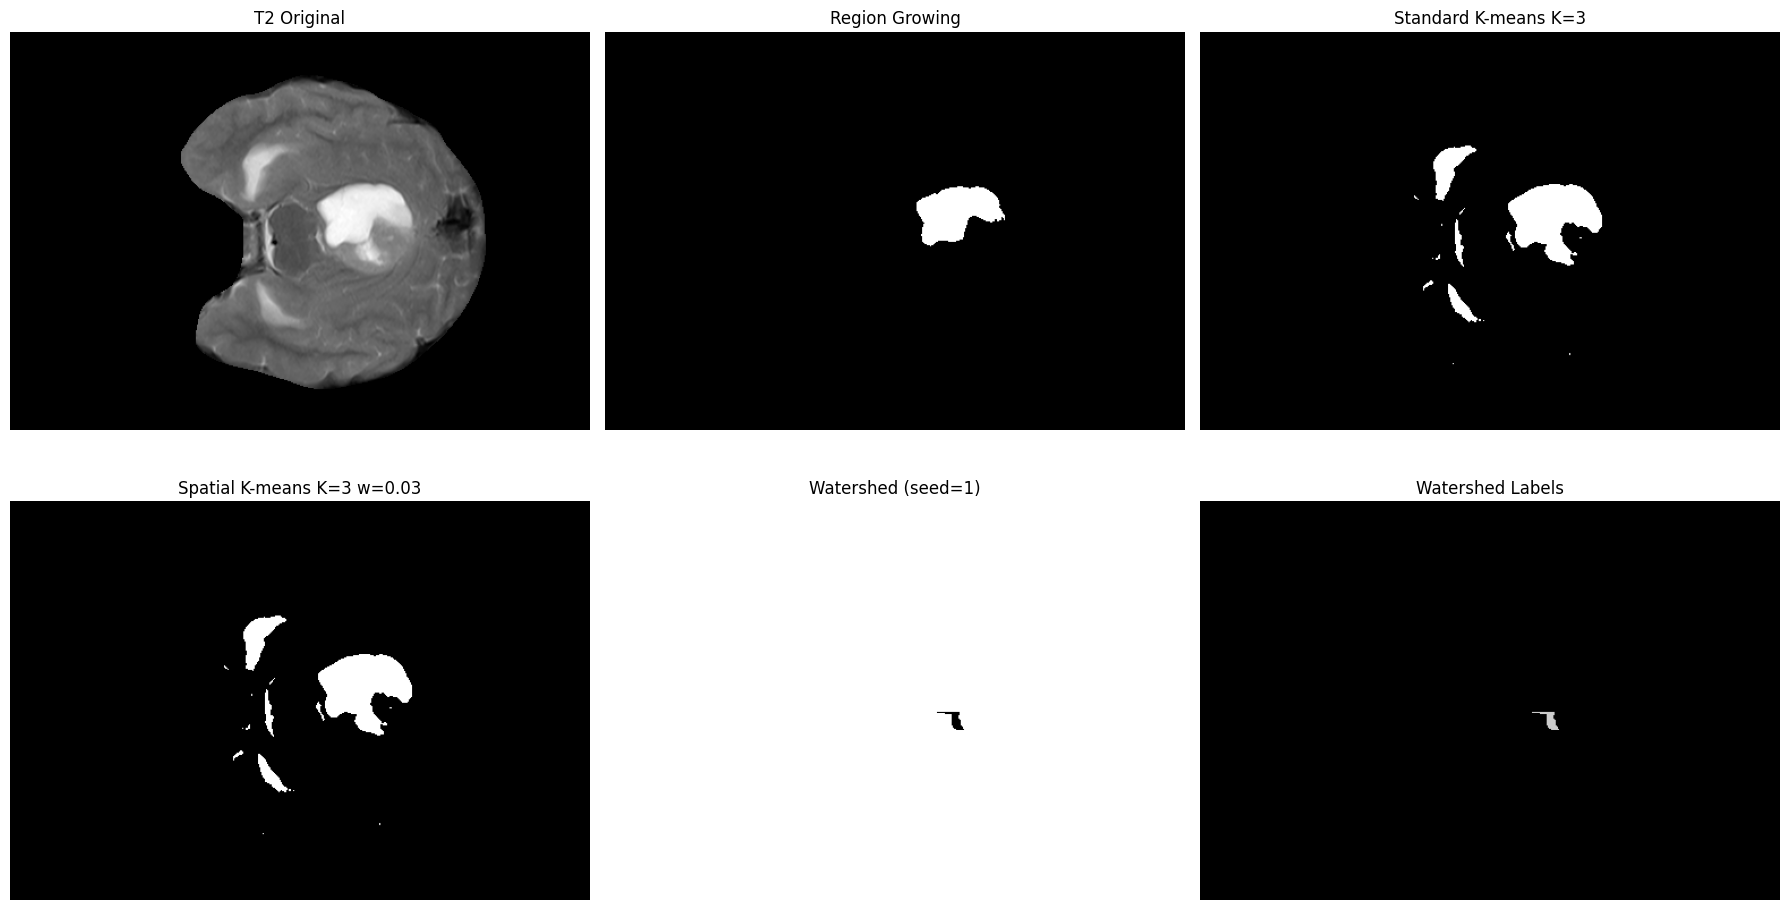

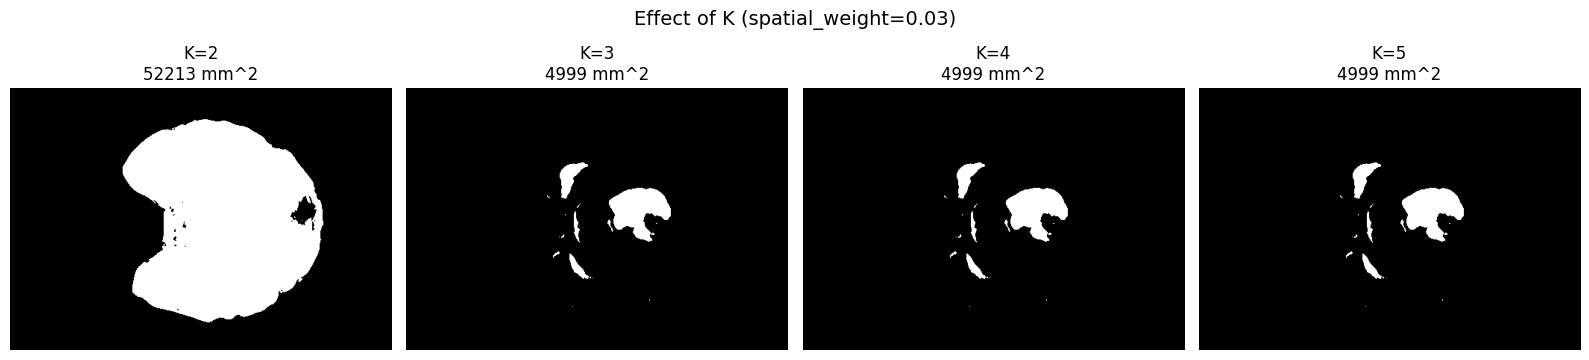

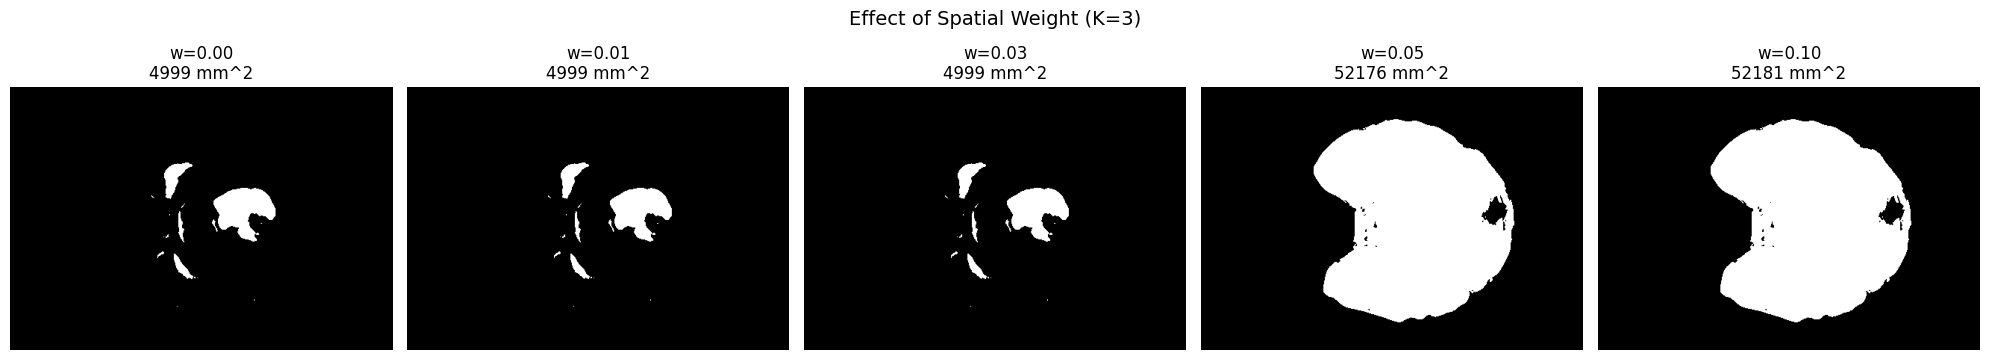

In [75]:
# ==================== Project 3: T2 分割与体积计算（完整版） ====================

def region_growing(img, seed, thresh):
    h, w = img.shape
    mask = np.zeros_like(img, dtype=bool)
    stack = [seed]
    seed_val = img[seed]
    while stack:
        y, x = stack.pop()
        if mask[y, x]:
            continue
        if abs(float(img[y, x]) - float(seed_val)) <= thresh:
            mask[y, x] = True
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not mask[ny, nx]:
                        stack.append((ny, nx))
    return mask

def kmeans(img, K=3, spatial_weight=0.0, iterations=20):
    h, w = img.shape
    coords_y, coords_x = np.indices(img.shape)
    features = np.stack([img.ravel(),
                         coords_y.ravel() * spatial_weight,
                         coords_x.ravel() * spatial_weight], axis=1)
    rng = np.random.default_rng(123)
    centers = features[rng.choice(features.shape[0], size=K, replace=False)]
    labels = np.zeros(features.shape[0], dtype=int)
    for _ in range(iterations):
        d = np.linalg.norm(features[:, None] - centers[None, :], axis=2)
        labels = np.argmin(d, axis=1)
        for k in range(K):
            members = features[labels == k]
            if len(members):
                centers[k] = members.mean(axis=0)
    return labels.reshape(h, w), centers

def lesion_area(mask):
    return mask.sum() * 1.0  # 1mm x 1mm resolution

# ==================== 1. Region Growing ====================
seed = np.unravel_index(np.argmax(T2), T2.shape)
region_mask = region_growing(T2, seed, thresh=230)

# ==================== 2. Improved K-means: test K and spatial_weight ====================
K_values = [2, 3, 4, 5]
weight_values = [0.0, 0.01, 0.03, 0.05, 0.1]

kmeans_results = {}
for K in K_values:
    for w in weight_values:
        labels, centers = kmeans(T2, K=K, spatial_weight=w)
        intensity_order = np.argsort(centers[:, 0])
        lesion_cluster = intensity_order[-1]
        mask = labels == lesion_cluster
        kmeans_results[(K, w)] = (mask, labels, centers)
        area = lesion_area(mask)
        print(f'K={K}, spatial_weight={w:.3f} -> area={area:.0f} mm^2')

# ==================== 3. Watershed ====================
img_int = (T2 - T2.min()).astype(np.uint16)
markers = np.zeros(T2.shape, dtype=np.int32)
markers[seed] = 1
markers[min(seed[0] + 20, T2.shape[0] - 1), min(seed[1] + 20, T2.shape[1] - 1)] = 2
watershed_label = ndi.watershed_ift(img_int, markers)
watershed_mask = watershed_label == 1

# ==================== 4. Standard vs Spatial-weighted K-means ====================
compare_weights = [0.0, 0.01, 0.03, 0.05, 0.1]
compare_masks = {}
for w in compare_weights:
    labels, centers = kmeans(T2, K=3, spatial_weight=w)
    lesion_cluster = np.argmax(centers[:, 0])
    compare_masks[w] = labels == lesion_cluster

# ==================== 5. Summary ====================
print('\n===== Lesion Area Summary =====')
print(f'Region Growing:          {lesion_area(region_mask):.0f} mm^2')
print(f'Watershed:               {lesion_area(watershed_mask):.0f} mm^2')
for w in compare_weights:
    print(f'K-means K=3 w={w:.2f}:       {lesion_area(compare_masks[w]):.0f} mm^2')

# ==================== Visualization ====================
# -- Figure 1: Four methods overview (2x3) --
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(T2, cmap='gray')
axes[0, 0].set_title('T2 Original')
axes[0, 1].imshow(region_mask, cmap='gray')
axes[0, 1].set_title('Region Growing')
km_std_mask, _, _ = kmeans_results[(3, 0.0)]
axes[0, 2].imshow(km_std_mask, cmap='gray')
axes[0, 2].set_title('Standard K-means K=3')
km_sp_mask, _, _ = kmeans_results[(3, 0.03)]
axes[1, 0].imshow(km_sp_mask, cmap='gray')
axes[1, 0].set_title('Spatial K-means K=3 w=0.03')
axes[1, 1].imshow(watershed_mask, cmap='gray')
axes[1, 1].set_title('Watershed (seed=1)')
axes[1, 2].imshow(watershed_label, cmap='nipy_spectral')
axes[1, 2].set_title('Watershed Labels')
for ax in axes.ravel():
    ax.axis('off')
fig.tight_layout()
plt.show()

# -- Figure 2: Effect of K (spatial_weight=0.03) --
fig, axes = plt.subplots(1, len(K_values), figsize=(4*len(K_values), 4))
for i, K in enumerate(K_values):
    mask, _, _ = kmeans_results[(K, 0.03)]
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f'K={K}\n{lesion_area(mask):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of K (spatial_weight=0.03)', fontsize=14)
fig.tight_layout()
plt.show()

# -- Figure 3: Effect of spatial_weight (K=3) --
fig, axes = plt.subplots(1, len(compare_weights), figsize=(4*len(compare_weights), 4))
for i, w in enumerate(compare_weights):
    axes[i].imshow(compare_masks[w], cmap='gray')
    axes[i].set_title(f'w={w:.2f}\n{lesion_area(compare_masks[w]):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of Spatial Weight (K=3)', fontsize=14)
fig.tight_layout()
plt.show()


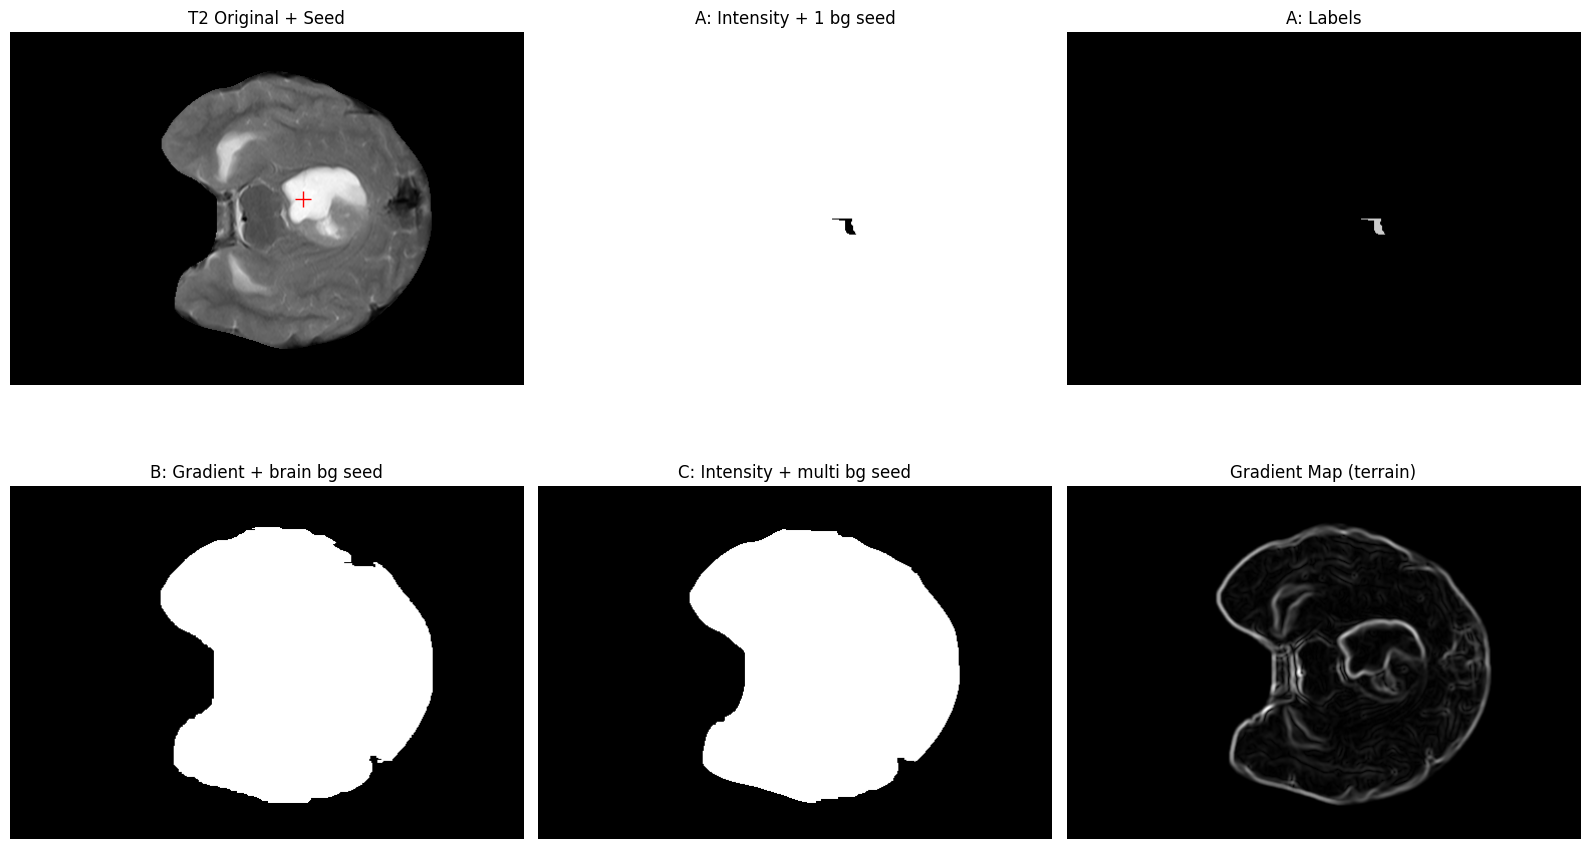

Lesion area A: 180087 mm^2
Lesion area B: 55318 mm^2
Lesion area C: 54045 mm^2


In [76]:
# ==================== Watershed 调参对比 ====================

# -- 方案A: 原版（原始强度 + 随意背景种子） --
img_int = (T2 - T2.min()).astype(np.uint16)
markers_A = np.zeros(T2.shape, dtype=np.int32)
markers_A[seed] = 1
markers_A[min(seed[0] + 20, T2.shape[0] - 1), min(seed[1] + 20, T2.shape[1] - 1)] = 2
label_A = ndi.watershed_ift(img_int, markers_A)

# -- 方案B: 梯度幅值作地形 + 脑外背景种子 --
# 梯度图作为地形：边缘处高（难穿过），均匀区域低（易填充）
grad, _, _ = sobel_gradients(preprocess(T2, sigma=2.0))
grad_int = (grad - grad.min()).astype(np.uint16)
# 背景种子放在脑掩码外的角落（真正的背景）
bm = brain_mask(T2)
bg_candidates = np.where(~bm)
bg_seed = (bg_candidates[0][len(bg_candidates[0]) // 2],
           bg_candidates[1][len(bg_candidates[1]) // 2])  # 脑外区域中心

markers_B = np.zeros(T2.shape, dtype=np.int32)
markers_B[seed] = 1
markers_B[bg_seed] = 2
label_B = ndi.watershed_ift(grad_int, markers_B)

# -- 方案C: 原始强度 + 多背景种子 --
markers_C = np.zeros(T2.shape, dtype=np.int32)
markers_C[seed] = 1
# 在脑掩码边缘附近撒多个背景种子
h, w = T2.shape
for pos in [(0, 0), (0, w-1), (h-1, 0), (h-1, w-1), (h//2, 0), (h//2, w-1)]:
    markers_C[pos] = 2
label_C = ndi.watershed_ift(img_int, markers_C)

# ==================== 对比可视化 ====================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(T2, cmap='gray')
axes[0, 0].plot(seed[1], seed[0], 'r+', markersize=12)
axes[0, 0].set_title('T2 Original + Seed')

axes[0, 1].imshow(label_A == 1, cmap='gray')
axes[0, 1].set_title('A: Intensity + 1 bg seed')

axes[0, 2].imshow(label_A, cmap='nipy_spectral')
axes[0, 2].set_title('A: Labels')

axes[1, 0].imshow(label_B == 1, cmap='gray')
axes[1, 0].set_title('B: Gradient + brain bg seed')

axes[1, 1].imshow(label_C == 1, cmap='gray')
axes[1, 1].set_title('C: Intensity + multi bg seed')

axes[1, 2].imshow(grad, cmap='gray')
axes[1, 2].set_title('Gradient Map (terrain)')

for ax in axes.ravel():
    ax.axis('off')
fig.tight_layout()
plt.show()

print(f"Lesion area A: {lesion_area(label_A == 1):.0f} mm^2")
print(f"Lesion area B: {lesion_area(label_B == 1):.0f} mm^2")
print(f"Lesion area C: {lesion_area(label_C == 1):.0f} mm^2")


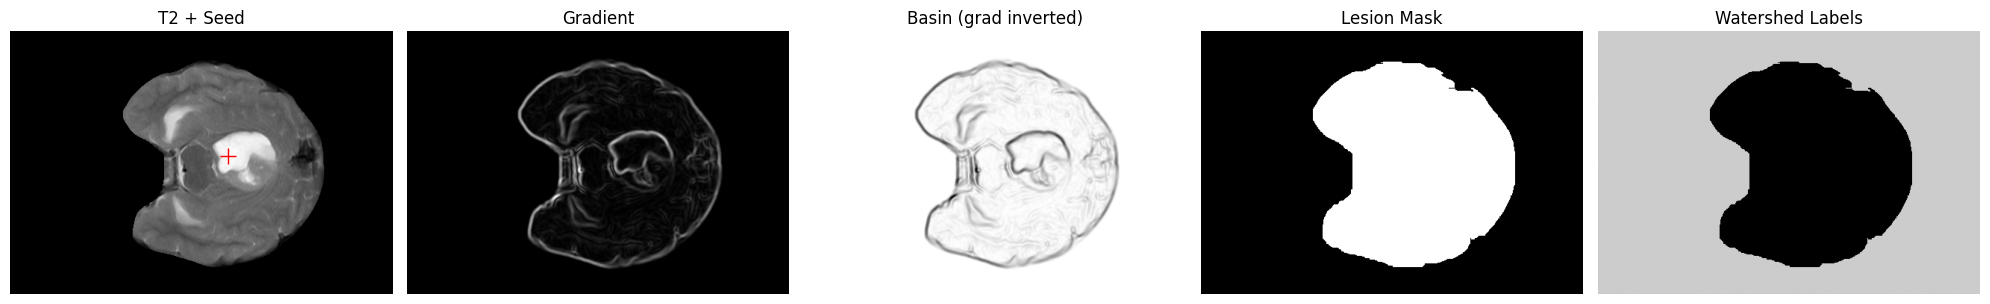

Lesion area: 55388 mm^2


In [77]:
# ==================== Watershed 修正版 ====================
from scipy import ndimage as ndi

# 1. 计算梯度幅值
smooth = preprocess(T2, sigma=2.0)
grad, _, _ = sobel_gradients(smooth)

# 2. 梯度反转：均匀区域(低梯度) → 高值 → 先处理(盆地)
#             边界(高梯度)     → 低值 → 后处理(山脊) → 水流停在此处
basin = (grad.max() - grad).astype(np.uint16)

# 3. 多个背景种子：放在图像角落和脑掩码外
bm = brain_mask(T2)
markers = np.zeros(T2.shape, dtype=np.int32)
markers[seed] = 1  # 病灶种子
h, w = T2.shape
corners = [(0, 0), (0, w-1), (h-1, 0), (h-1, w-1),
           (0, w//2), (h-1, w//2), (h//2, 0), (h//2, w-1)]
for cy, cx in corners:
    markers[min(cy, h-1), min(cx, w-1)] = 2

# 4. 分水岭
watershed_label = ndi.watershed_ift(basin, markers)
watershed_mask = watershed_label == 1

# ==================== 对比可视化 ====================
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(T2, cmap='gray')
axes[0].plot(seed[1], seed[0], 'r+', markersize=12)
axes[0].set_title('T2 + Seed')

axes[1].imshow(grad, cmap='gray')
axes[1].set_title('Gradient')

axes[2].imshow(basin, cmap='gray')
axes[2].set_title('Basin (grad inverted)')

axes[3].imshow(watershed_mask, cmap='gray')
axes[3].set_title('Lesion Mask')

axes[4].imshow(watershed_label, cmap='nipy_spectral')
axes[4].set_title('Watershed Labels')

for ax in axes.ravel():
    ax.axis('off')
fig.tight_layout()
plt.show()

print(f'Lesion area: {lesion_area(watershed_mask):.0f} mm^2')



Project 3: T2 Segmentation & Volume
Seed: (np.int64(166), np.int64(292)), value=1127

--- K-means Grid Search ---
K=2, w=0.000 -> area=52213 mm^2
K=2, w=0.010 -> area=52213 mm^2
K=2, w=0.030 -> area=52213 mm^2
K=2, w=0.050 -> area=52213 mm^2
K=2, w=0.100 -> area=52213 mm^2
K=3, w=0.000 -> area=4999 mm^2
K=3, w=0.010 -> area=4999 mm^2
K=3, w=0.030 -> area=4999 mm^2
K=3, w=0.050 -> area=52176 mm^2
K=3, w=0.100 -> area=52181 mm^2
K=4, w=0.000 -> area=4706 mm^2
K=4, w=0.010 -> area=4746 mm^2
K=4, w=0.030 -> area=4999 mm^2
K=4, w=0.050 -> area=52176 mm^2
K=4, w=0.100 -> area=52178 mm^2
K=5, w=0.000 -> area=4509 mm^2
K=5, w=0.010 -> area=4732 mm^2
K=5, w=0.030 -> area=4999 mm^2
K=5, w=0.050 -> area=4999 mm^2
K=5, w=0.100 -> area=4999 mm^2

===== Lesion Volume Summary =====
Region Growing:           1374 mm^2
Watershed:                3029 mm^2
K-means K=3 w=0.00:        4999 mm^2
K-means K=3 w=0.01:        4999 mm^2
K-means K=3 w=0.03:        4999 mm^2
K-means K=3 w=0.05:        52176 mm^2


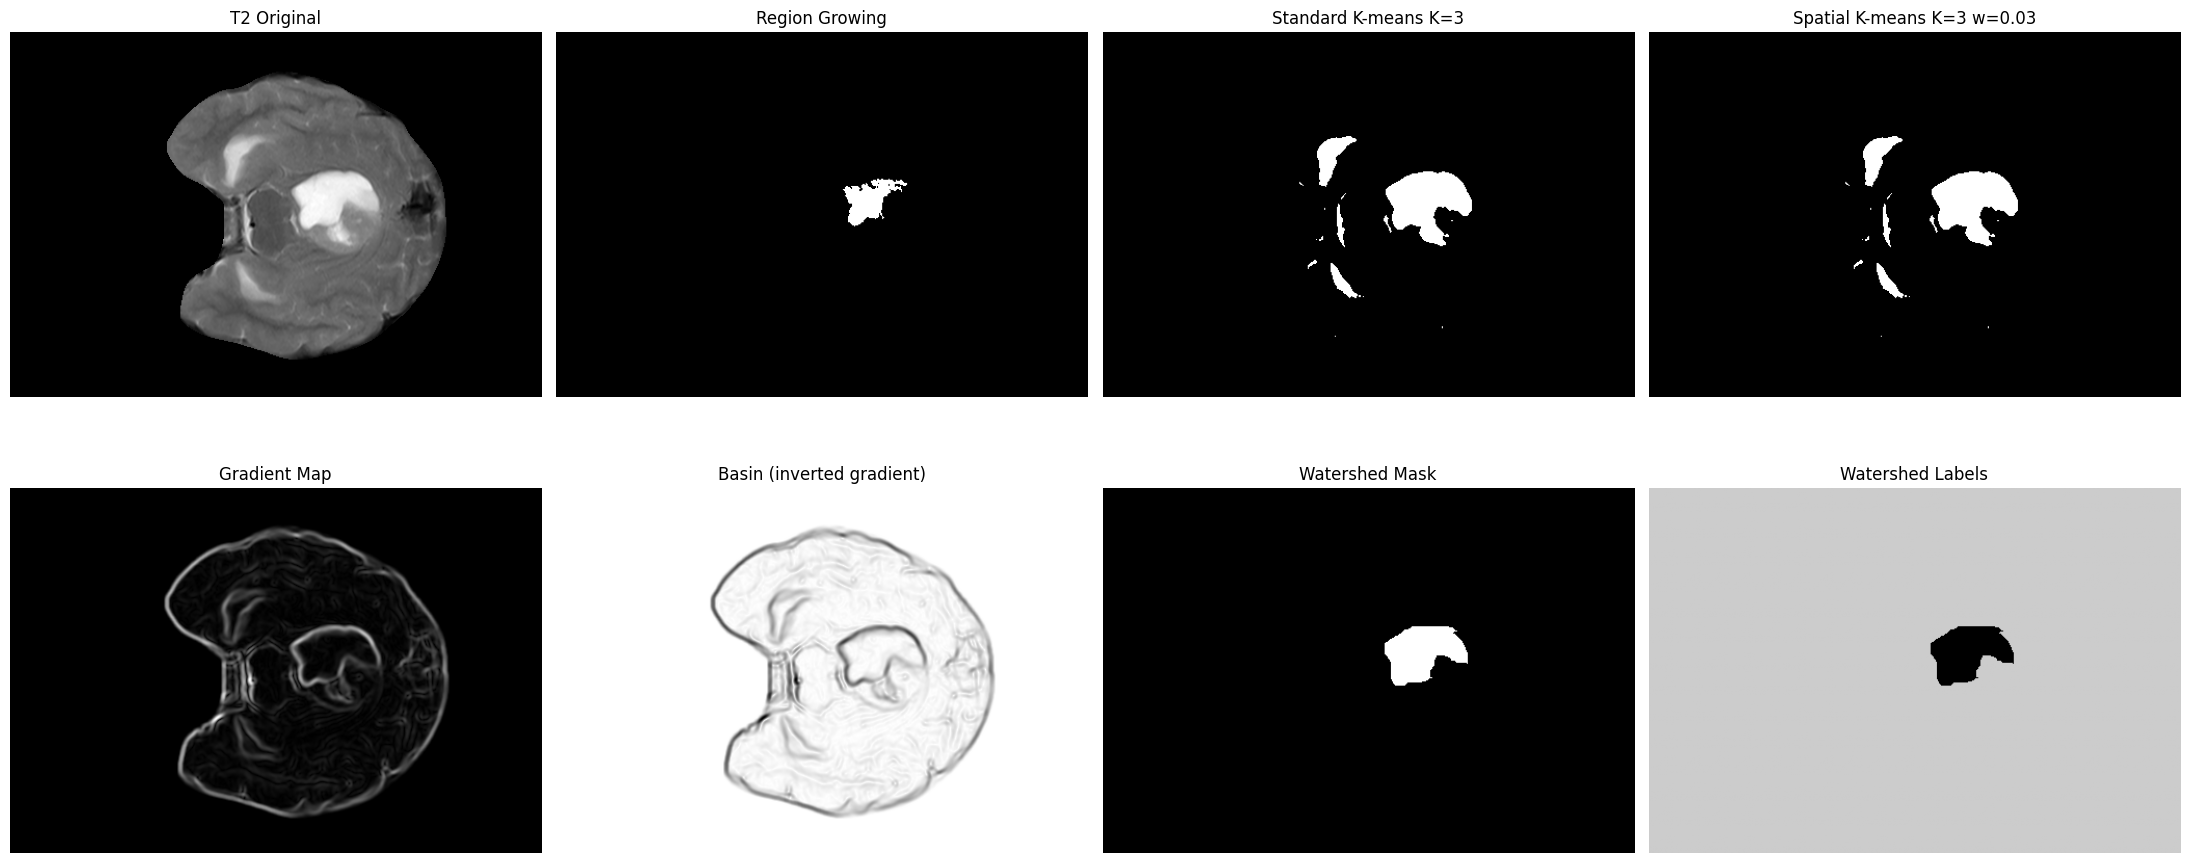

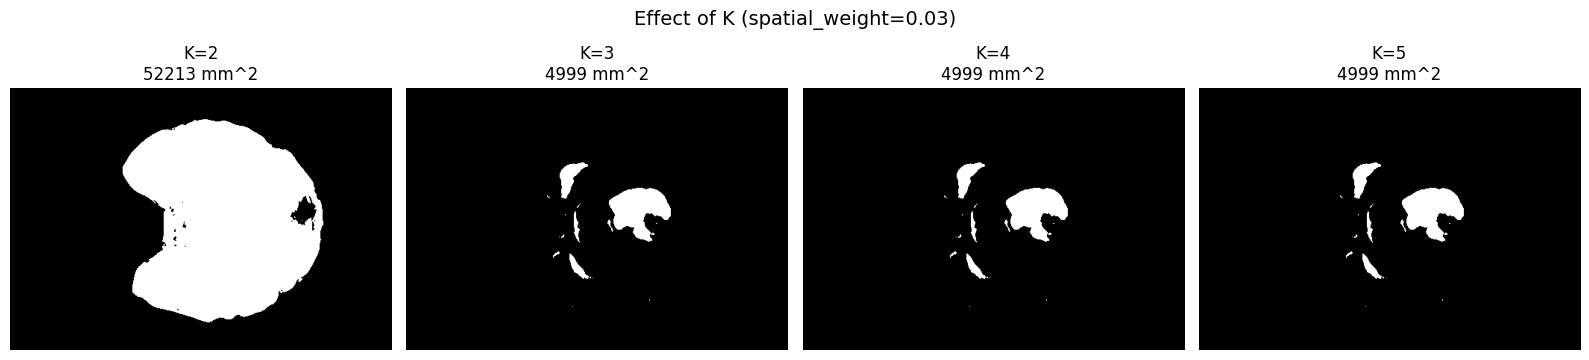

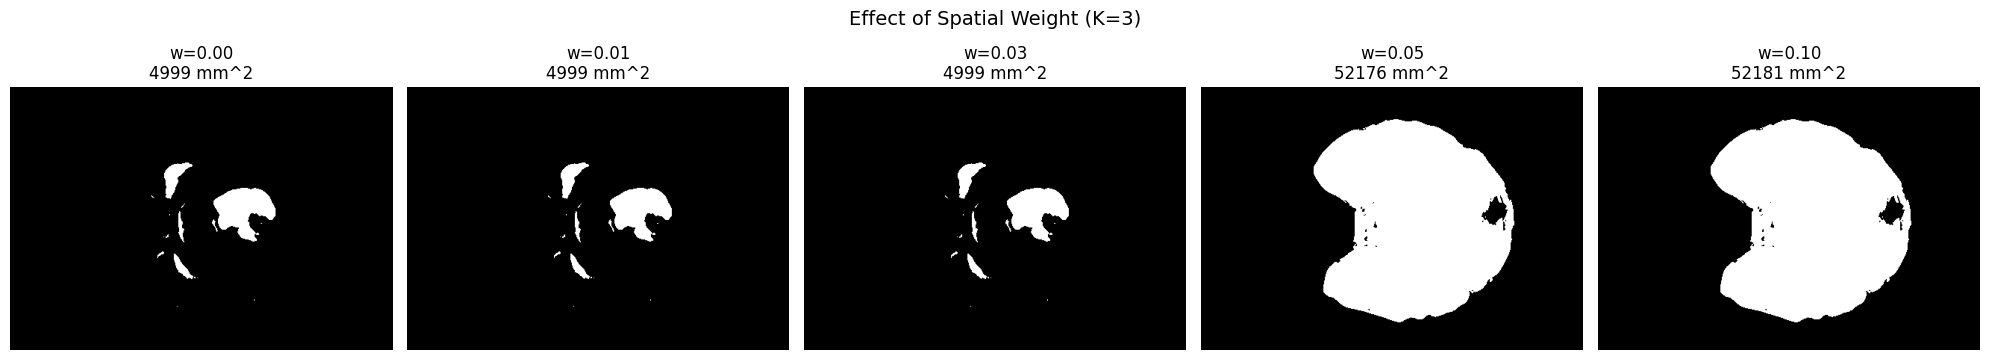

In [79]:
# ============================================================
#   Project 3: T2 区域分割与体积计算
# ============================================================

def region_growing(img, seed, thresh):
    h, w = img.shape
    mask = np.zeros_like(img, dtype=bool)
    stack = [seed]
    seed_val = img[seed]
    while stack:
        y, x = stack.pop()
        if mask[y, x]:
            continue
        if abs(float(img[y, x]) - float(seed_val)) <= thresh:
            mask[y, x] = True
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not mask[ny, nx]:
                        stack.append((ny, nx))
    return mask

def kmeans(img, K=3, spatial_weight=0.0, iterations=20):
    h, w = img.shape
    coords_y, coords_x = np.indices(img.shape)
    features = np.stack([img.ravel(),
                         coords_y.ravel() * spatial_weight,
                         coords_x.ravel() * spatial_weight], axis=1)
    rng = np.random.default_rng(123)
    centers = features[rng.choice(features.shape[0], size=K, replace=False)]
    labels = np.zeros(features.shape[0], dtype=int)
    for _ in range(iterations):
        d = np.linalg.norm(features[:, None] - centers[None, :], axis=2)
        labels = np.argmin(d, axis=1)
        for k in range(K):
            members = features[labels == k]
            if len(members):
                centers[k] = members.mean(axis=0)
    return labels.reshape(h, w), centers

def lesion_area(mask):
    return mask.sum() * 1.0  # 1mm x 1mm resolution

print('\n' + '=' * 50)
print('Project 3: T2 Segmentation & Volume')
print('=' * 50)

seed = np.unravel_index(np.argmax(T2), T2.shape)
print(f'Seed: {seed}, value={T2[seed]:.0f}')

# -------- 1. Region Growing --------
region_mask = region_growing(T2, seed, thresh=80)

# -------- 2. K-means: K x spatial_weight 网格搜索 --------
K_values = [2, 3, 4, 5]
weight_values = [0.0, 0.01, 0.03, 0.05, 0.1]

kmeans_results = {}
print('\n--- K-means Grid Search ---')
for K in K_values:
    for w in weight_values:
        labels, centers = kmeans(T2, K=K, spatial_weight=w)
        lesion_cluster = np.argsort(centers[:, 0])[-1]
        mask = labels == lesion_cluster
        kmeans_results[(K, w)] = (mask, labels, centers)
        print(f'K={K}, w={w:.3f} -> area={lesion_area(mask):.0f} mm^2')

# -------- 3. Watershed (原始梯度版) --------
smooth_T2 = preprocess(T2, sigma=2.0)
grad_T2, _, _ = sobel_gradients(smooth_T2)

# 原始梯度归一化到 [0, 255]: 边界(高梯度) → 高代价 → 屏障
#                          均匀区(低梯度) → 低代价 → 水流容易穿过
grad_int = (grad_T2 / grad_T2.max() * 255).astype(np.uint16)

# 病灶种子: T2 最亮像素
seed = np.unravel_index(np.argmax(T2), T2.shape)

# 背景种子: 脑掩码外的所有区域
bm = brain_mask(T2)
markers = np.zeros(T2.shape, dtype=np.int32)
markers[seed] = 1
markers[~bm] = 2

watershed_label = ndi.watershed_ift(grad_int, markers)
watershed_mask = watershed_label == 1

# -------- 4. Standard vs Spatial-weighted K-means (K=3) --------
compare_weights = [0.0, 0.01, 0.03, 0.05, 0.1]
compare_masks = {}
for w in compare_weights:
    labels, centers = kmeans(T2, K=3, spatial_weight=w)
    lesion_cluster = np.argmax(centers[:, 0])
    compare_masks[w] = labels == lesion_cluster

# -------- 5. Volume Summary --------
print('\n===== Lesion Volume Summary =====')
print(f'Region Growing:           {lesion_area(region_mask):.0f} mm^2')
print(f'Watershed:                {lesion_area(watershed_mask):.0f} mm^2')
for w in compare_weights:
    print(f'K-means K=3 w={w:.2f}:        {lesion_area(compare_masks[w]):.0f} mm^2')

# -------- 可视化 --------
# -- Figure 1: 四种方法总览 (2x4) --
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

axes[0, 0].imshow(T2, cmap='gray')
axes[0, 0].set_title('T2 Original')
axes[0, 1].imshow(region_mask, cmap='gray')
axes[0, 1].set_title('Region Growing')

km_std_mask, _, _ = kmeans_results[(3, 0.0)]
axes[0, 2].imshow(km_std_mask, cmap='gray')
axes[0, 2].set_title('Standard K-means K=3')

km_sp_mask, _, _ = kmeans_results[(3, 0.03)]
axes[0, 3].imshow(km_sp_mask, cmap='gray')
axes[0, 3].set_title('Spatial K-means K=3 w=0.03')

axes[1, 0].imshow(grad_T2, cmap='gray')
axes[1, 0].set_title('Gradient Map')
axes[1, 1].imshow(basin, cmap='gray')
axes[1, 1].set_title('Basin (inverted gradient)')
axes[1, 2].imshow(watershed_mask, cmap='gray')
axes[1, 2].set_title('Watershed Mask')
axes[1, 3].imshow(watershed_label, cmap='nipy_spectral')
axes[1, 3].set_title('Watershed Labels')

for ax in axes.ravel():
    ax.axis('off')
fig.tight_layout()
plt.show()

# -- Figure 2: K 值影响 (固定 w=0.03) --
fig, axes = plt.subplots(1, len(K_values), figsize=(4*len(K_values), 4))
for i, K in enumerate(K_values):
    mask, _, _ = kmeans_results[(K, 0.03)]
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f'K={K}\n{lesion_area(mask):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of K (spatial_weight=0.03)', fontsize=14)
fig.tight_layout()
plt.show()

# -- Figure 3: spatial_weight 影响 (固定 K=3) --
fig, axes = plt.subplots(1, len(compare_weights), figsize=(4*len(compare_weights), 4))
for i, w in enumerate(compare_weights):
    axes[i].imshow(compare_masks[w], cmap='gray')
    axes[i].set_title(f'w={w:.2f}\n{lesion_area(compare_masks[w]):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of Spatial Weight (K=3)', fontsize=14)
fig.tight_layout()
plt.show()

K=25, spatial_weight=0.000 -> area=2199 mm^2
K=25, spatial_weight=0.010 -> area=2199 mm^2
K=25, spatial_weight=0.030 -> area=2199 mm^2
K=25, spatial_weight=0.050 -> area=2199 mm^2
K=25, spatial_weight=0.100 -> area=2199 mm^2
K=20, spatial_weight=0.000 -> area=2348 mm^2
K=20, spatial_weight=0.010 -> area=2348 mm^2
K=20, spatial_weight=0.030 -> area=2348 mm^2
K=20, spatial_weight=0.050 -> area=2348 mm^2
K=20, spatial_weight=0.100 -> area=2348 mm^2
K=15, spatial_weight=0.000 -> area=3436 mm^2
K=15, spatial_weight=0.010 -> area=3416 mm^2
K=15, spatial_weight=0.030 -> area=3448 mm^2
K=15, spatial_weight=0.050 -> area=3481 mm^2
K=15, spatial_weight=0.100 -> area=3572 mm^2
K=3, spatial_weight=0.000 -> area=4999 mm^2
K=3, spatial_weight=0.010 -> area=4999 mm^2
K=3, spatial_weight=0.030 -> area=4999 mm^2
K=3, spatial_weight=0.050 -> area=52176 mm^2
K=3, spatial_weight=0.100 -> area=52181 mm^2

===== Lesion Area Summary =====
Region Growing:          2595 mm^2
Watershed:               3029 mm^2


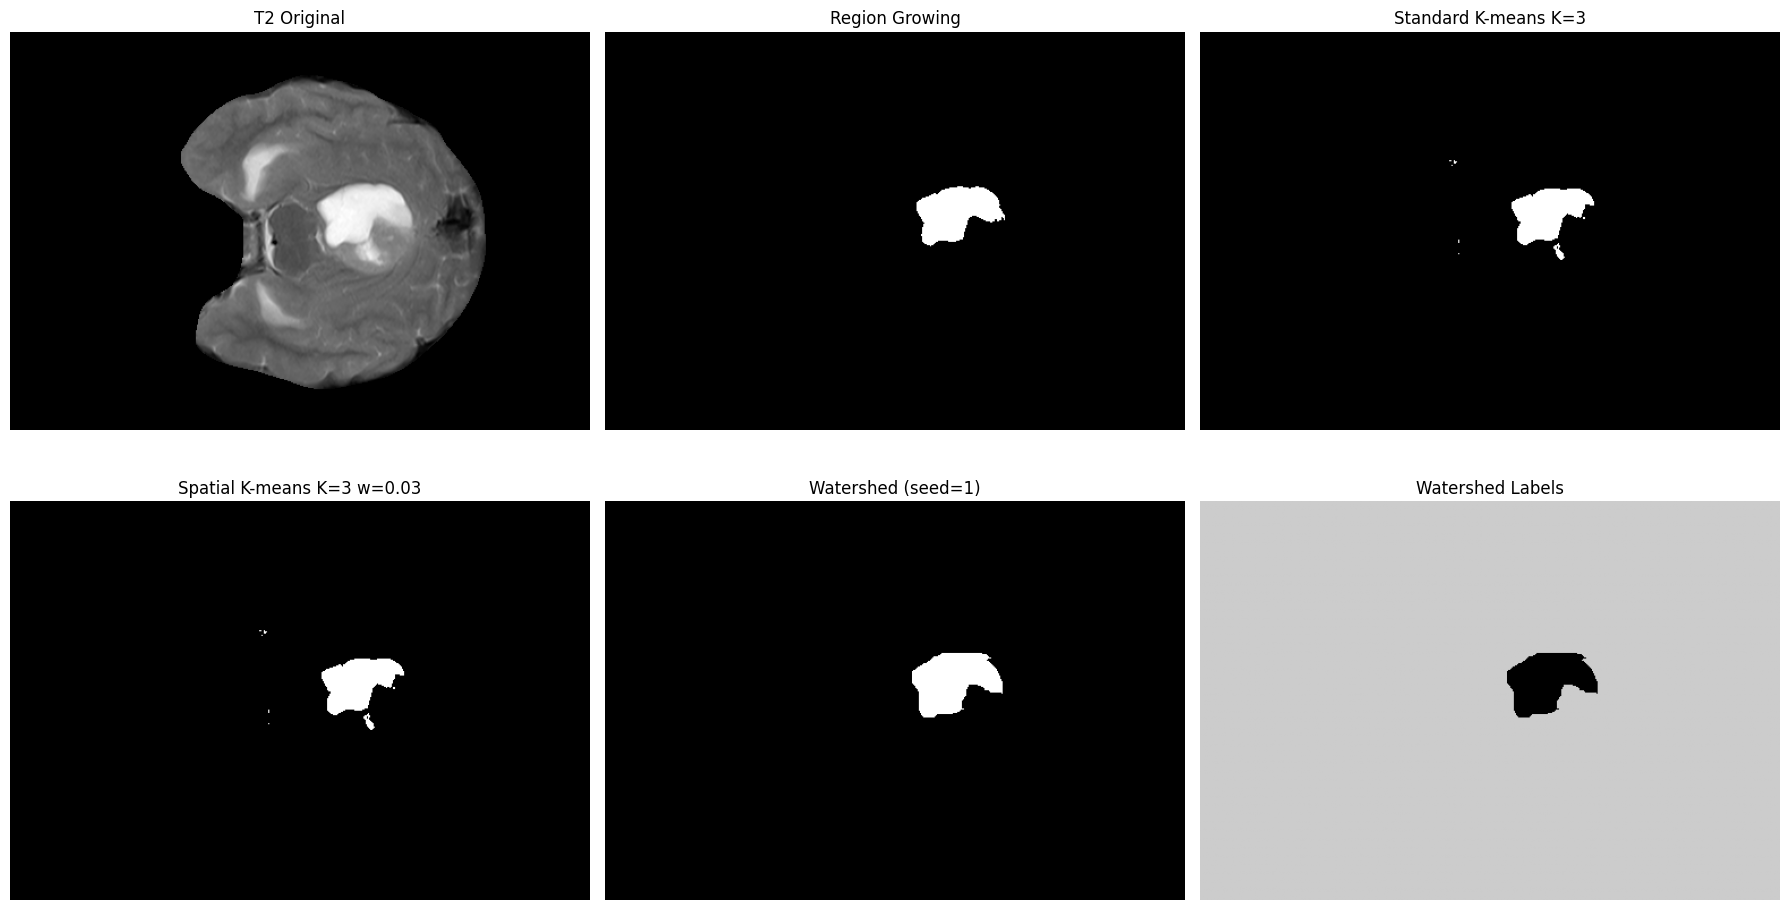

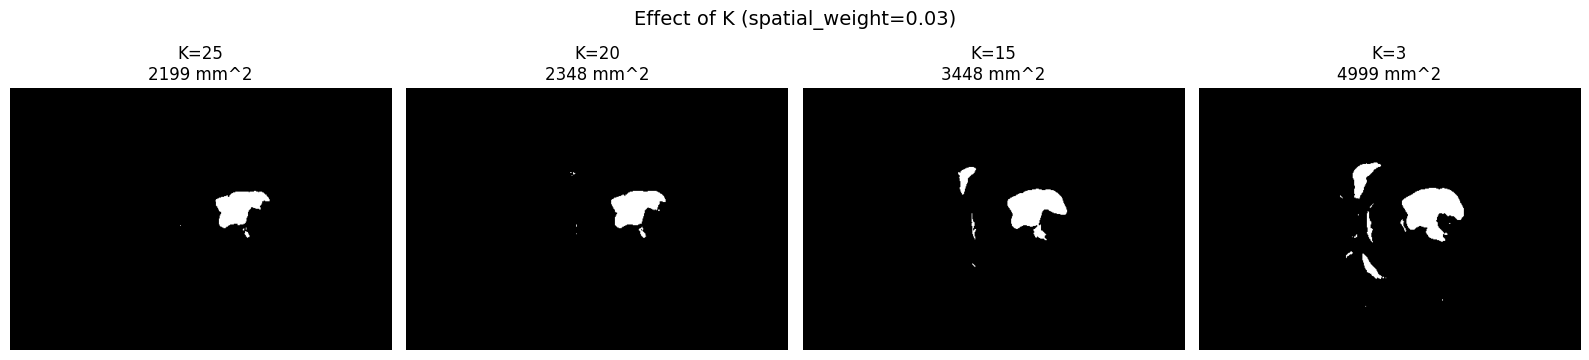

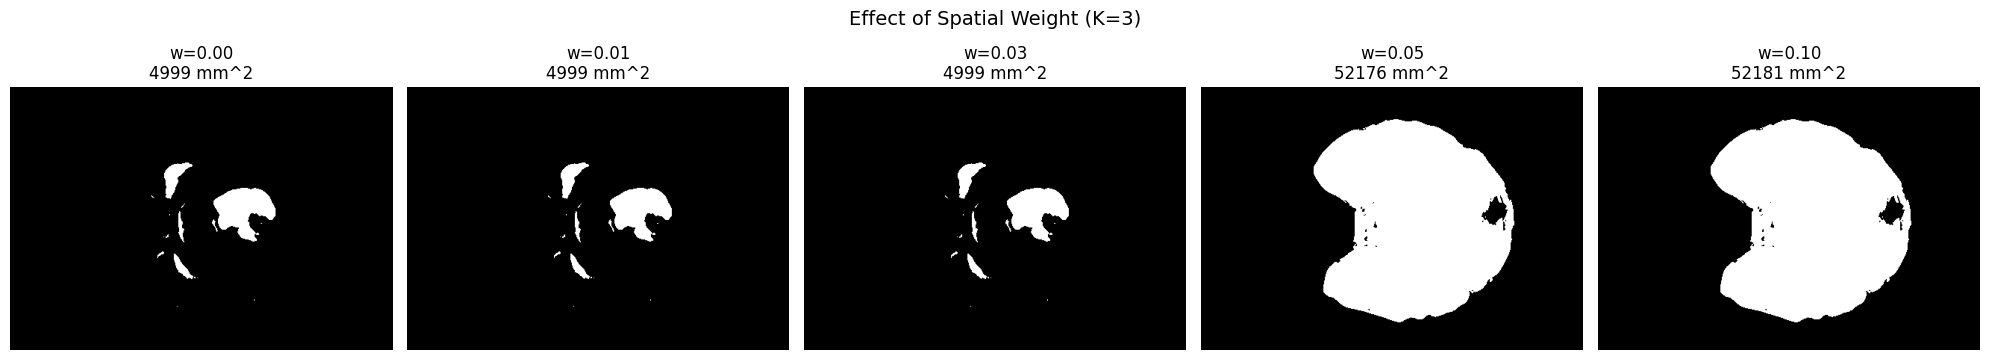

In [80]:
# ==================== Project 3 ====================

# 区域生长：从种子点扩展到强度相近像素，得到连续病灶区域
def region_growing(img, seed, thresh):
    h, w = img.shape
    mask = np.zeros_like(img, dtype=bool)
    stack = [seed]
    seed_val = img[seed]
    while stack:
        y, x = stack.pop()
        if mask[y, x]:
            continue
        if abs(float(img[y, x]) - float(seed_val)) <= thresh:
            mask[y, x] = True
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not mask[ny, nx]:
                        stack.append((ny, nx))
    return mask
# K-means 聚类：可选加入空间权重，使分割结果更具空间一致性
def kmeans(img, K=3, spatial_weight=0.0, iterations=20):
    h, w = img.shape
    coords_y, coords_x = np.indices(img.shape)
    features = np.stack([img.ravel(),
                         coords_y.ravel() * spatial_weight,
                         coords_x.ravel() * spatial_weight], axis=1)
    rng = np.random.default_rng(123)
    centers = features[rng.choice(features.shape[0], size=K, replace=False)]
    labels = np.zeros(features.shape[0], dtype=int)
    for _ in range(iterations):
        d = np.linalg.norm(features[:, None] - centers[None, :], axis=2)
        labels = np.argmin(d, axis=1)
        for k in range(K):
            members = features[labels == k]
            if len(members):
                centers[k] = members.mean(axis=0)
    return labels.reshape(h, w), centers
# 计算病灶区域面积，假定像素分辨率为 1mm x 1mm
def lesion_area(mask):
    return mask.sum() * 1.0  # 1mm x 1mm resolution

# ==================== 1. Region Growing ====================
seed = np.unravel_index(np.argmax(T2), T2.shape)
region_mask = region_growing(T2, seed, thresh=230)

# ==================== 2. Improved K-means: test K and spatial_weight ====================
# K_values = [2, 3, 4, 5]
K_values = [25,20,15,3]
weight_values = [0.0, 0.01, 0.03, 0.05, 0.1]

kmeans_results = {}
for K in K_values:
    for w in weight_values:
        labels, centers = kmeans(T2, K=K, spatial_weight=w)
        intensity_order = np.argsort(centers[:, 0])
        lesion_cluster = intensity_order[-1]
        mask = labels == lesion_cluster
        kmeans_results[(K, w)] = (mask, labels, centers)
        area = lesion_area(mask)
        print(f'K={K}, spatial_weight={w:.3f} -> area={area:.0f} mm^2')

# -------- 3. Watershed (原始梯度版) --------
smooth_T2 = preprocess(T2, sigma=2.0)
grad_T2, _, _ = sobel_gradients(smooth_T2)

# 原始梯度归一化到 [0, 255]: 边界(高梯度) → 高代价 → 屏障
#                          均匀区(低梯度) → 低代价 → 水流容易穿过
grad_int = (grad_T2 / grad_T2.max() * 255).astype(np.uint16)

# 病灶种子: T2 最亮像素
seed = np.unravel_index(np.argmax(T2), T2.shape)

# 背景种子: 脑掩码外的所有区域
bm = brain_mask(T2)
markers = np.zeros(T2.shape, dtype=np.int32)
markers[seed] = 1
markers[~bm] = 2

watershed_label = ndi.watershed_ift(grad_int, markers)
watershed_mask = watershed_label == 1

# ==================== 4. Standard vs Spatial-weighted K-means ====================
compare_weights = [0.0, 0.01, 0.03, 0.05, 0.1]
compare_masks = {}
for w in compare_weights:
    labels, centers = kmeans(T2, K=3, spatial_weight=w)
    lesion_cluster = np.argmax(centers[:, 0])
    compare_masks[w] = labels == lesion_cluster

# ==================== 5. Summary ====================
print('\n===== Lesion Area Summary =====')
print(f'Region Growing:          {lesion_area(region_mask):.0f} mm^2')
print(f'Watershed:               {lesion_area(watershed_mask):.0f} mm^2')
for w in compare_weights:
    print(f'K-means K=3 w={w:.2f}:       {lesion_area(compare_masks[w]):.0f} mm^2')

# ==================== Visualization ====================
# -- Figure 1: Four methods overview (2x3) --
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(T2, cmap='gray')
axes[0, 0].set_title('T2 Original')
axes[0, 1].imshow(region_mask, cmap='gray')
axes[0, 1].set_title('Region Growing')
km_std_mask, _, _ = kmeans_results[(20, 0.0)]
axes[0, 2].imshow(km_std_mask, cmap='gray')
axes[0, 2].set_title('Standard K-means K=3')
km_sp_mask, _, _ = kmeans_results[(20, 0.03)]
axes[1, 0].imshow(km_sp_mask, cmap='gray')
axes[1, 0].set_title('Spatial K-means K=3 w=0.03')
axes[1, 1].imshow(watershed_mask, cmap='gray')
axes[1, 1].set_title('Watershed (seed=1)')
axes[1, 2].imshow(watershed_label, cmap='nipy_spectral')
axes[1, 2].set_title('Watershed Labels')
for ax in axes.ravel():
    ax.axis('off')
fig.tight_layout()
plt.show()

# -- Figure 2: Effect of K (spatial_weight=0.03) --
fig, axes = plt.subplots(1, len(K_values), figsize=(4*len(K_values), 4))
for i, K in enumerate(K_values):
    mask, _, _ = kmeans_results[(K, 0.03)]
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f'K={K}\n{lesion_area(mask):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of K (spatial_weight=0.03)', fontsize=14)
fig.tight_layout()
plt.show()

# -- Figure 3: Effect of spatial_weight (K=3) --
fig, axes = plt.subplots(1, len(compare_weights), figsize=(4*len(compare_weights), 4))
for i, w in enumerate(compare_weights):
    axes[i].imshow(compare_masks[w], cmap='gray')
    axes[i].set_title(f'w={w:.2f}\n{lesion_area(compare_masks[w]):.0f} mm^2')
    axes[i].axis('off')
fig.suptitle('Effect of Spatial Weight (K=3)', fontsize=14)
fig.tight_layout()
plt.show()


